# Lung Cancer VOC Dataset — Complete ML Pipeline

This notebook implements:

- TXT → CSV and JSON conversion
- Dataset inspection and feature-wise statistics
- Class distribution and extensive visualization
- Data quality checks and required preprocessing only
- Feature engineering and feature selection
- 20+ classification models
- 15+ regression models
- Classification and regression performance metrics
- Model comparison and selection
- Hyperparameter tuning
- SHAP explainability
- Saving trained objects as `.pkl`
- Files/results suitable for a Streamlit dashboard

> **Important:** `Class` is used only for classification (`Control`, `Benign`, `Cancer`).  
> Regression is treated separately as VOC-concentration prediction and does **not** convert the class labels into arbitrary numeric targets.


In [5]:
# Install once if required
# !pip install pandas numpy scipy matplotlib seaborn scikit-learn xgboost lightgbm catboost shap plotly streamlit joblib openpyxl

In [6]:
import os
import json
import time
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
OUTPUT_DIR = BASE_DIR / "outputs"
EDA_DIR = OUTPUT_DIR / "eda"
CLASS_DIR = OUTPUT_DIR / "classification"
REG_DIR = OUTPUT_DIR / "regression"
SHAP_DIR = OUTPUT_DIR / "shap"

for d in [DATA_DIR, MODEL_DIR, OUTPUT_DIR, EDA_DIR, CLASS_DIR, REG_DIR, SHAP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


## 1. Load Dataset and Convert TXT to CSV/JSON

In [7]:
DATASET_PATHS = [
    Path("LungCancer.txt"),
    Path("Pasted text.txt"),
    Path("/mnt/data/Pasted text.txt"),
    Path("/content/LungCancer.json")
]

dataset_path = next((p for p in DATASET_PATHS if p.exists()), None)

if dataset_path is None:
    raise FileNotFoundError(
        "Dataset not found. Place LungCancer.txt or LungCancer.json in the notebook folder."
    )

try:
    if dataset_path.suffix == ".json":
        df = pd.read_json(dataset_path)
    else:
        df = pd.read_csv(dataset_path, sep="\t")
except Exception:
    if dataset_path.suffix == ".json":
        df = pd.read_json(dataset_path)
    else:
        df = pd.read_csv(dataset_path, sep=None, engine="python")

df.columns = [str(c).strip() for c in df.columns]
df = df.replace([np.inf, -np.inf], np.nan)

print("Dataset:", dataset_path)
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())

Dataset: /content/LungCancer.json
Shape: (427, 29)
Columns:
['PatientID', 'CH2O', 'C2H4O', 'C3H6O', 'C4H8O', 'C5H10O', 'C6H12O', 'C7H14O', 'C8H16O', 'C9H18O', 'C10H20O', 'C11H22O', 'C12H24O', 'C13H26O', 'C4HO8O2', 'C2H4O2', 'C3H4O', 'C6H10O2', 'C9H16O2', 'C3H4O2', 'C4H6O2', 'C4H6O', 'C4H4O2', 'C5H8O', 'C7H6O', 'C7H11O', 'C13H22O', 'C15H10O', 'Class']


,PatientID,CH2O,C2H4O,C3H6O,C4H8O,C5H10O,C6H12O,C7H14O,C8H16O,C9H18O,C10H20O,C11H22O,C12H24O,C13H26O,C4HO8O2,C2H4O2,C3H4O,C6H10O2,C9H16O2,C3H4O2,C4H6O2,C4H6O,C4H4O2,C5H8O,C7H6O,C7H11O,C13H22O,C15H10O,Class
0,1,8.296,1.819,4.38,1.96,0.31,0.0000,0.0000,0.2425,1.8346,2.037503,0.530017,0.494061,0.296304,0.014,0.172,0.003203,0.000000,0.556762,0.000000,0.0,0.0,0.0,0.945508,0.001998,1.271775,0.435466,0.0,Control
1,2,0.812,0.712,4.77,1.77,0.39,0.0000,0.0000,0.0326,0.2368,1.178667,0.287248,0.238206,0.124873,0.018,0.107,0.013559,0.000000,0.008303,0.000878,0.0,0.0,0.0,0.313624,0.000000,0.717091,0.077891,0.0,Control
2,3,2.188,3.552,10.55,1.82,0.82,0.0146,0.0000,0.0851,0.5166,1.258489,0.154444,0.184776,0.045522,0.016,0.248,0.000000,0.000841,0.000000,0.000000,0.0,0.0,0.0,0.218656,0.000000,0.185854,0.000000,0.0,Control
3,4,1.546,1.952,4.37,1.82,0.65,0.0085,0.0000,0.0000,0.5896,0.982457,0.214458,0.174556,0.000000,0.176,0.320,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.257484,0.000000,0.227369,0.000000,0.0,Control
4,5,1.406,0.973,4.40,1.05,0.18,0.0027,0.0011,0.0313,0.2835,0.794009,0.219915,0.157876,0.038659,0.015,0.035,0.000576,0.000084,0.002300,0.000000,0.0,0.0,0.0,0.391217,0.000000,0.844936,0.088429,0.0,Control


In [8]:
csv_path = DATA_DIR / "lung_cancer.csv"
json_path = DATA_DIR / "lung_cancer.json"

df.to_csv(csv_path, index=False)
df.to_json(json_path, orient="records", indent=2)

print("Created:", csv_path)
print("Created:", json_path)


Created: data/lung_cancer.csv
Created: data/lung_cancer.json


## 2. Dataset Overview

In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

if "Class" in df.columns:
    print("\nClass distribution:")
    display(df["Class"].value_counts().to_frame("count"))
    display((df["Class"].value_counts(normalize=True) * 100).round(2).to_frame("percentage"))


Rows: 427
Columns: 29

Data types:


,dtype
PatientID,int64
CH2O,float64
C2H4O,float64
C3H6O,float64
C4H8O,float64
C5H10O,float64
C6H12O,float64
C7H14O,float64
C8H16O,float64
C9H18O,float64



Missing values:


,missing
PatientID,0
CH2O,0
C2H4O,0
C3H6O,0
C4H8O,0
C5H10O,0
C6H12O,0
C7H14O,0
C8H16O,0
C9H18O,0



Duplicate rows: 0

Class distribution:


,count
Class,
Control,193
Cancer,157
Benign,77


,percentage
Class,
Control,45.20
Cancer,36.77
Benign,18.03


## 3. Feature-wise Statistics

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
feature_cols = [c for c in numeric_cols if c != "PatientID"]

stats_rows = []

for col in feature_cols:
    s = df[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    row = {
        "feature": col,
        "dtype": str(s.dtype),
        "count": int(s.count()),
        "missing_count": int(s.isna().sum()),
        "missing_pct": float(s.isna().mean() * 100),
        "unique": int(s.nunique()),
        "zero_count": int((s == 0).sum()),
        "zero_pct": float((s == 0).mean() * 100),
        "min": s.min(),
        "max": s.max(),
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "variance": s.var(),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "skewness": s.skew(),
        "kurtosis": s.kurt(),
        "coefficient_of_variation": (s.std()/s.mean()) if s.mean() != 0 else np.nan,
        "outlier_count_iqr": int(((s < lower) | (s > upper)).sum())
    }
    stats_rows.append(row)

feature_statistics = pd.DataFrame(stats_rows)
feature_statistics.to_csv(OUTPUT_DIR / "feature_statistics.csv", index=False)
display(feature_statistics)


,feature,dtype,count,missing_count,missing_pct,unique,zero_count,zero_pct,min,max,mean,median,std,variance,q1,q3,iqr,skewness,kurtosis,coefficient_of_variation,outlier_count_iqr
0,CH2O,float64,427,0,0.0,352,0,0.000000,0.004000,8.296000,0.511938,0.314000,0.640984,4.108610e-01,0.161500,0.643500,0.482000,5.264824,52.049889,1.252074,31
1,C2H4O,float64,427,0,0.0,379,0,0.000000,0.080000,17.180000,2.147961,1.392000,2.393407,5.728398e+00,0.526392,2.905000,2.378608,2.571248,9.132024,1.114269,21
2,C3H6O,float64,427,0,0.0,353,0,0.000000,0.040000,36.820000,4.164770,3.410000,3.502088,1.226462e+01,2.009561,5.228501,3.218940,3.245308,20.321801,0.840884,23
3,C4H8O,float64,427,0,0.0,289,0,0.000000,0.200000,8.210000,2.191845,1.920000,1.343784,1.805756e+00,1.255000,2.800624,1.545624,1.486826,3.168797,0.613084,15
4,C5H10O,float64,427,0,0.0,288,0,0.000000,0.030000,7.110000,1.137228,1.028032,0.769466,5.920777e-01,0.610000,1.475000,0.865000,2.187699,10.636000,0.676616,15
5,C6H12O,float64,427,0,0.0,290,27,6.323185,0.000000,2.122000,0.089681,0.036000,0.179799,3.232775e-02,0.007150,0.104100,0.096950,6.036802,50.915390,2.004885,25
6,C7H14O,float64,427,0,0.0,244,96,22.482436,0.000000,1.016000,0.026383,0.007630,0.068689,4.718229e-03,0.000650,0.030150,0.029500,9.480805,118.804711,2.603521,36
7,C8H16O,float64,427,0,0.0,375,35,8.196721,0.000000,0.654734,0.062555,0.047387,0.082568,6.817403e-03,0.008650,0.089300,0.080650,3.851644,20.534433,1.319920,17
8,C9H18O,float64,427,0,0.0,416,5,1.170960,0.000000,2.998696,0.340781,0.267000,0.345401,1.193016e-01,0.111845,0.466758,0.354914,3.209042,16.343454,1.013555,18
9,C10H20O,float64,427,0,0.0,427,0,0.000000,0.000188,11.932903,0.849371,0.685857,0.875469,7.664458e-01,0.304700,1.218939,0.914239,5.762899,62.871833,1.030726,7


In [11]:
if "Class" in df.columns:
    class_counts = df["Class"].value_counts()
    class_stats = pd.DataFrame({
        "count": class_counts,
        "percentage": (class_counts / len(df) * 100).round(2)
    })

    imbalance_ratio = class_counts.max() / class_counts.min()
    print("Class imbalance ratio:", round(imbalance_ratio, 3))
    display(class_stats)


Class imbalance ratio: 2.506


,count,percentage
Class,,
Control,193,45.20
Cancer,157,36.77
Benign,77,18.03


## 4. Visualization / EDA

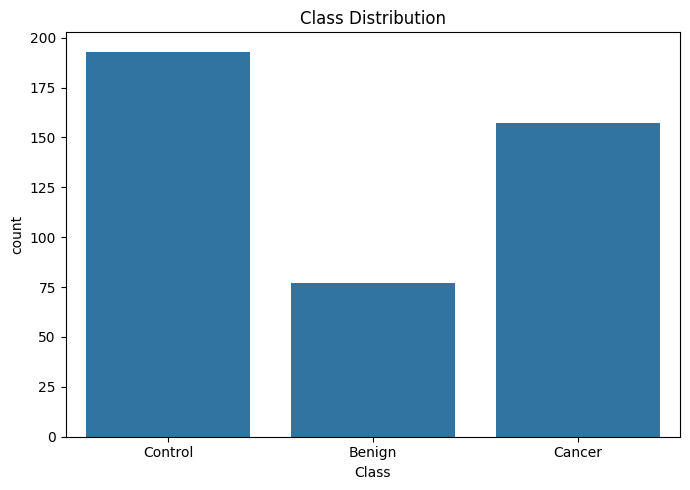

In [12]:
if "Class" in df.columns:
    plt.figure(figsize=(7,5))
    sns.countplot(data=df, x="Class")
    plt.title("Class Distribution")
    plt.tight_layout()
    plt.savefig(EDA_DIR / "class_distribution.png", dpi=200)
    plt.show()


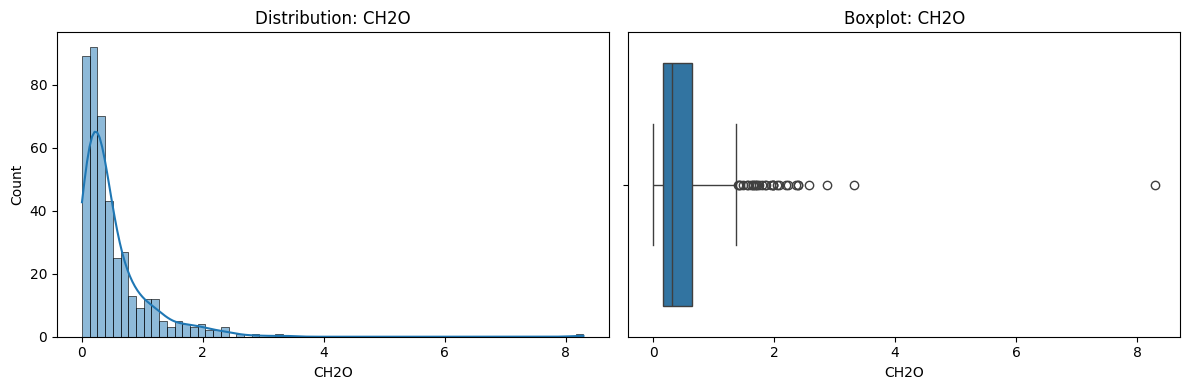

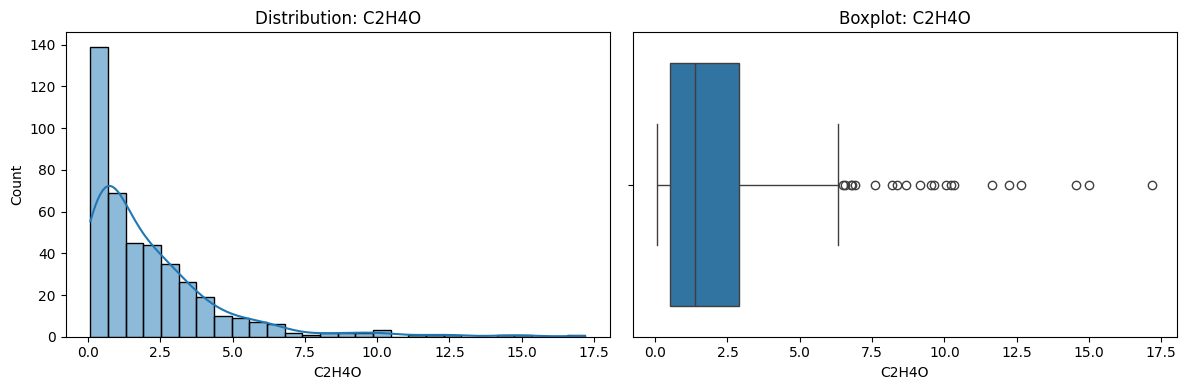

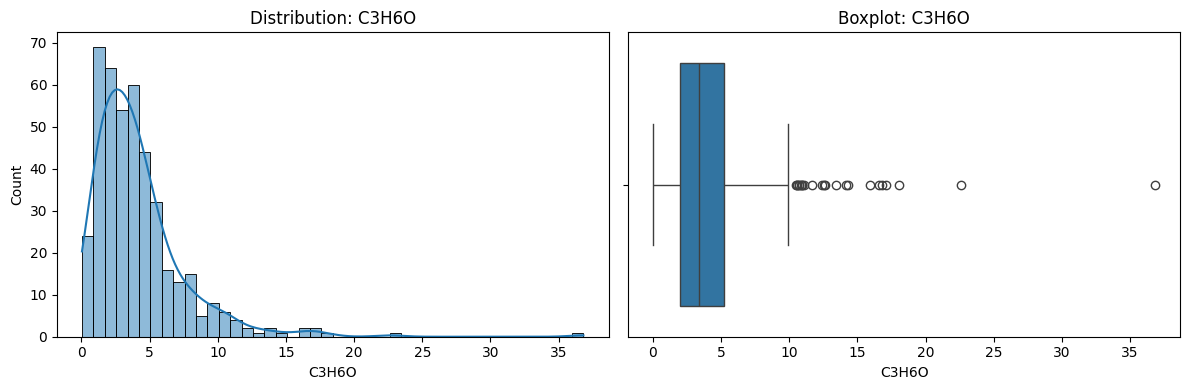

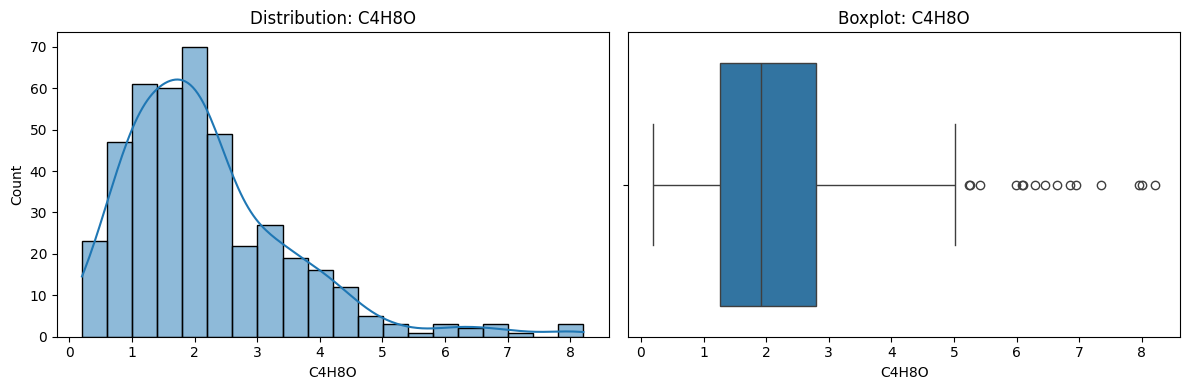

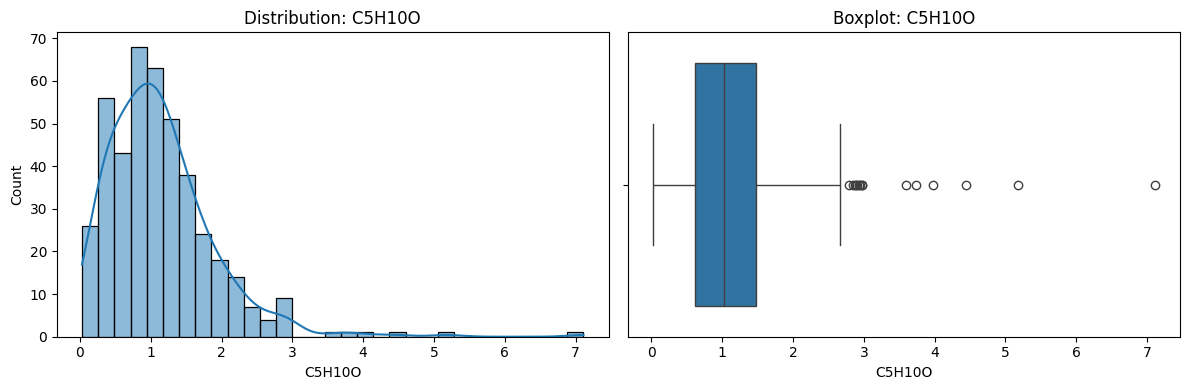

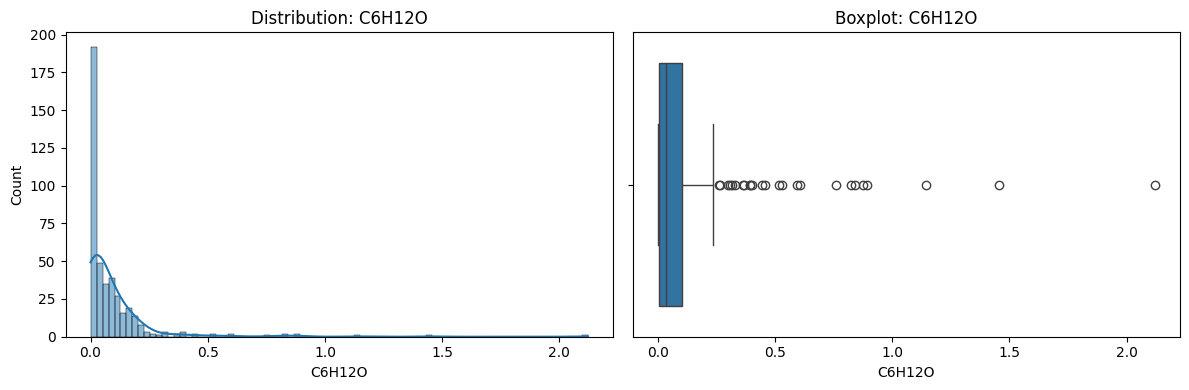

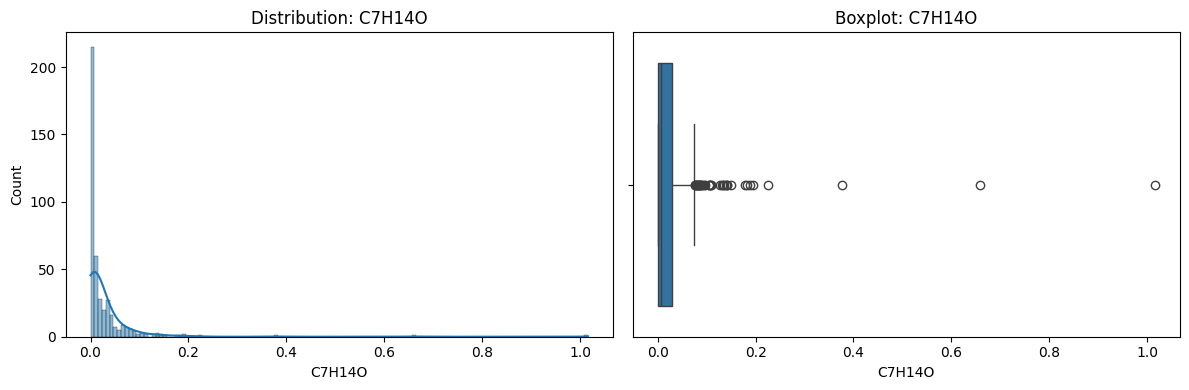

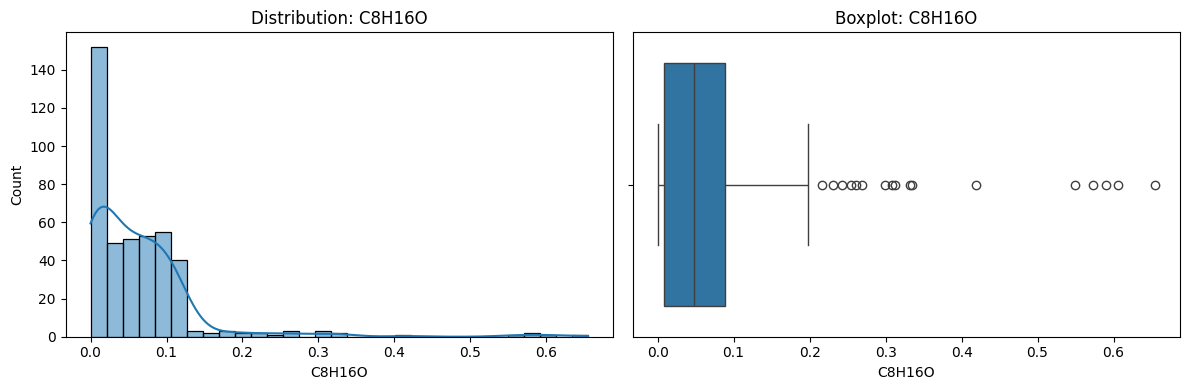

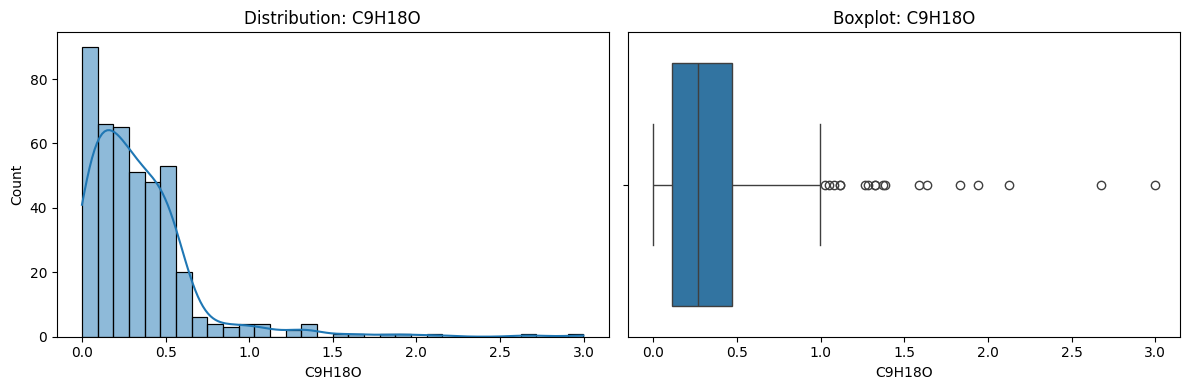

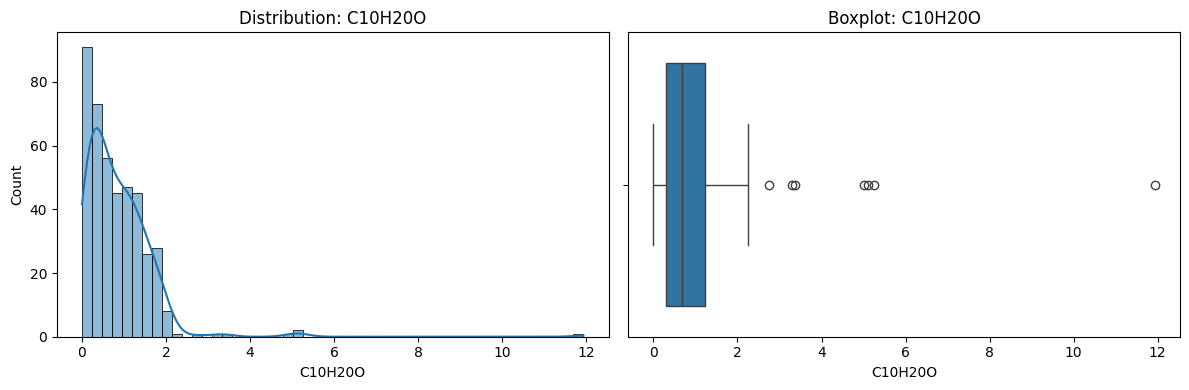

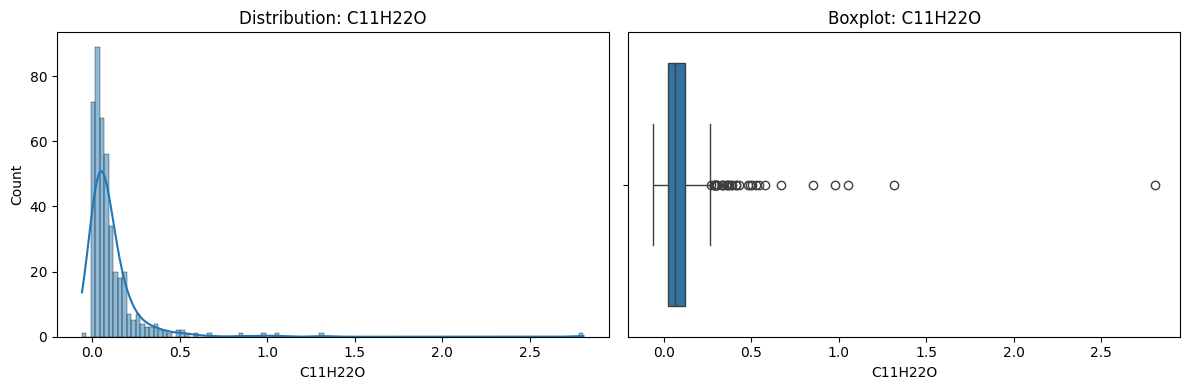

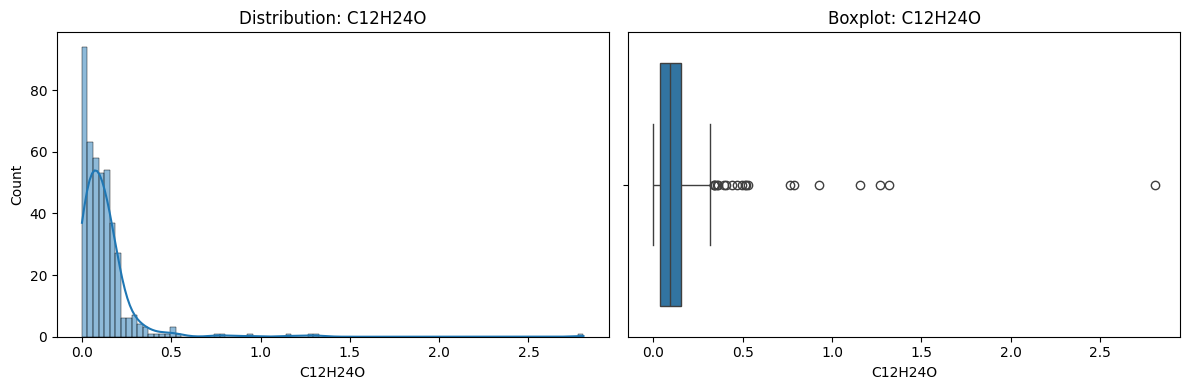

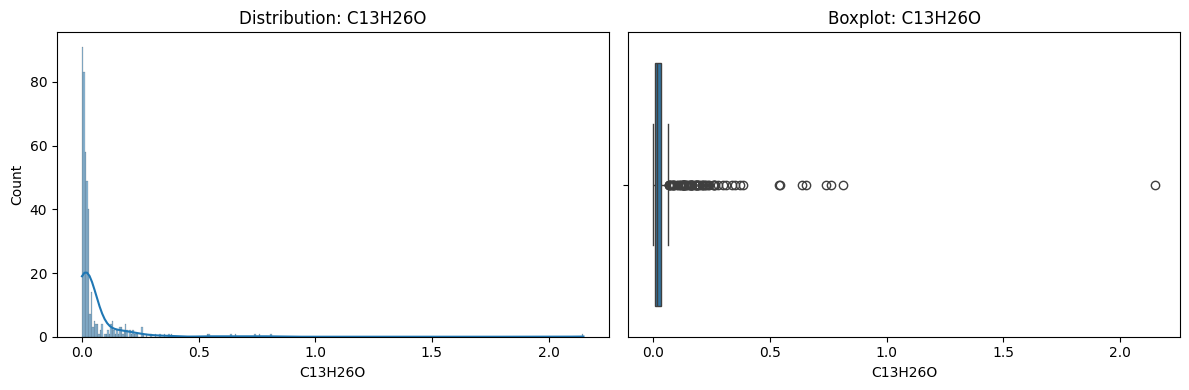

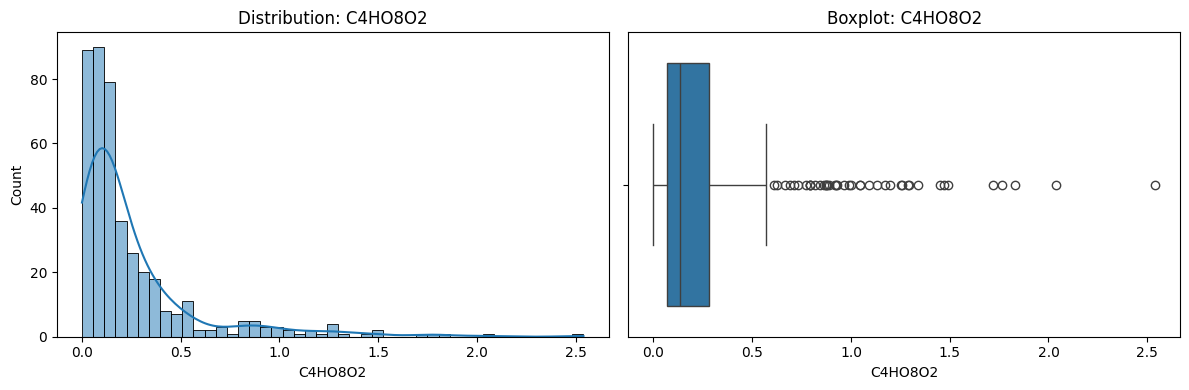

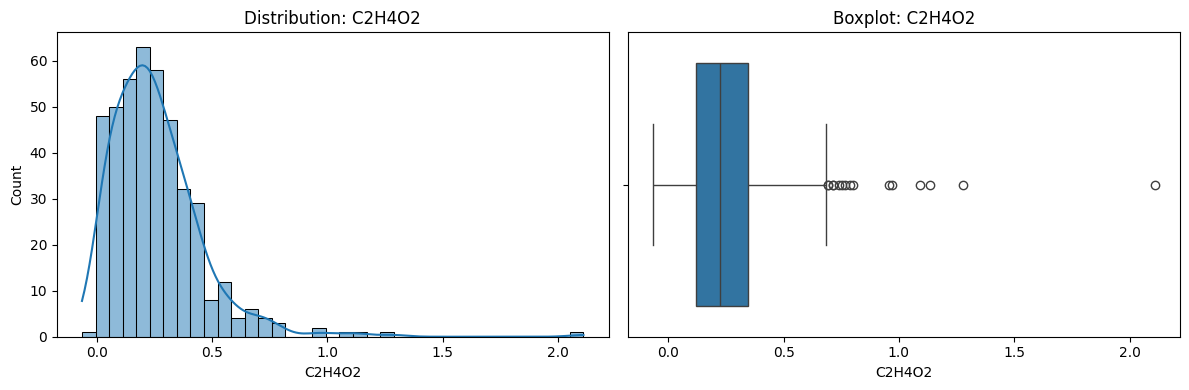

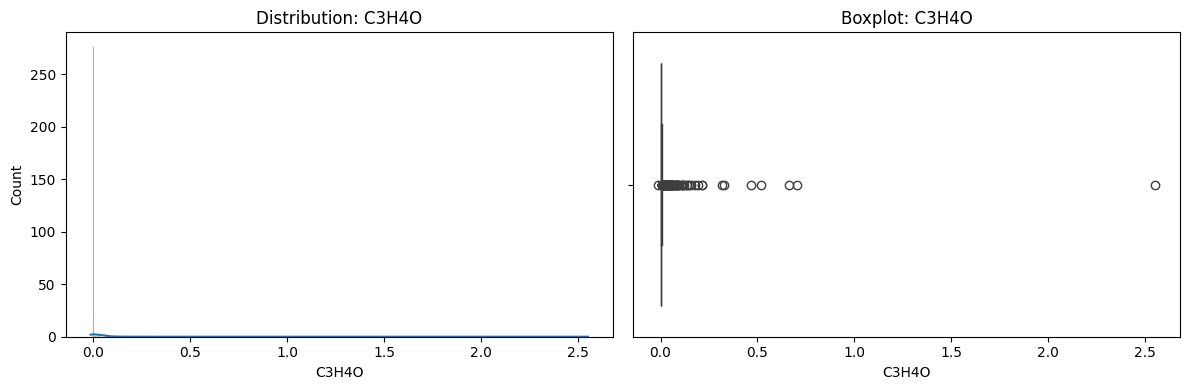

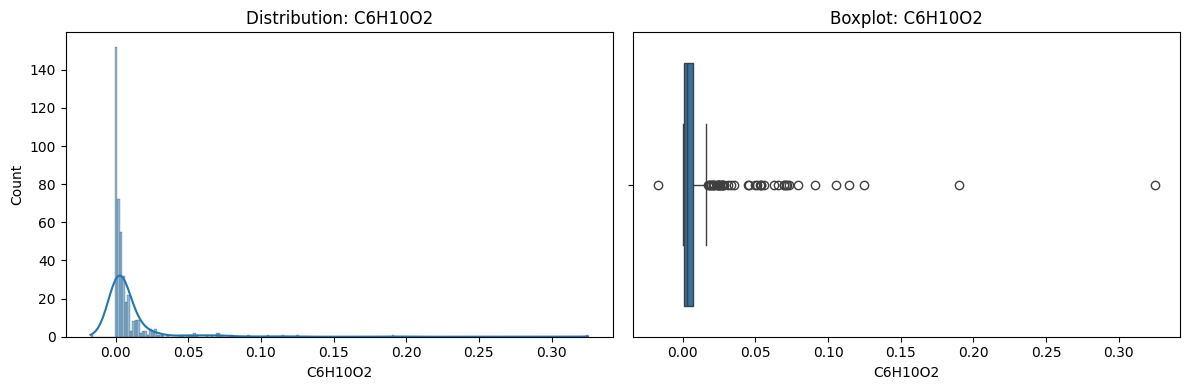

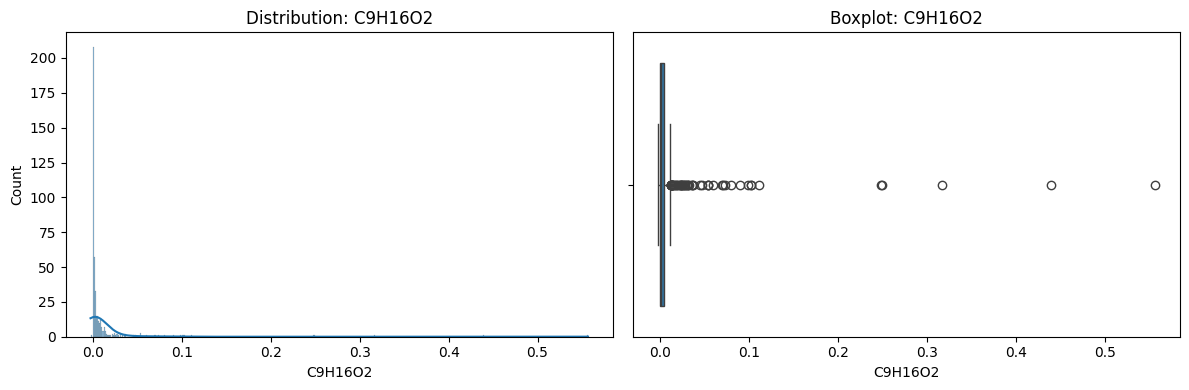

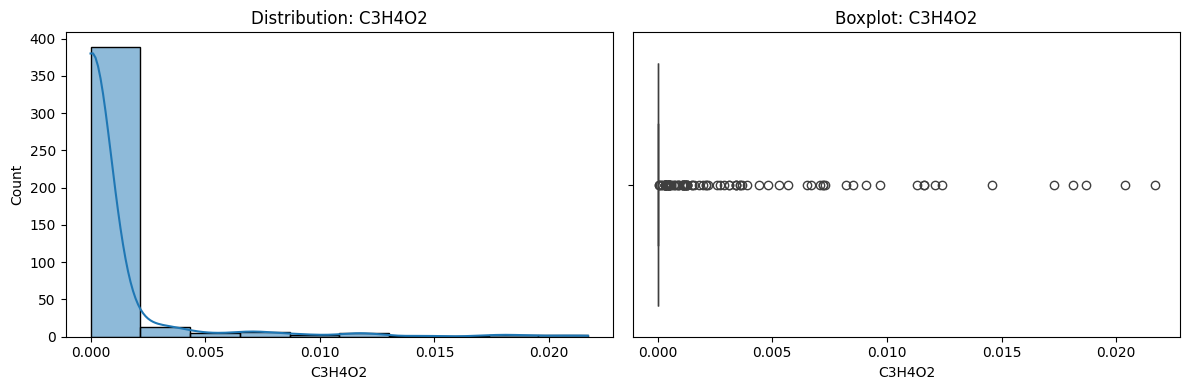

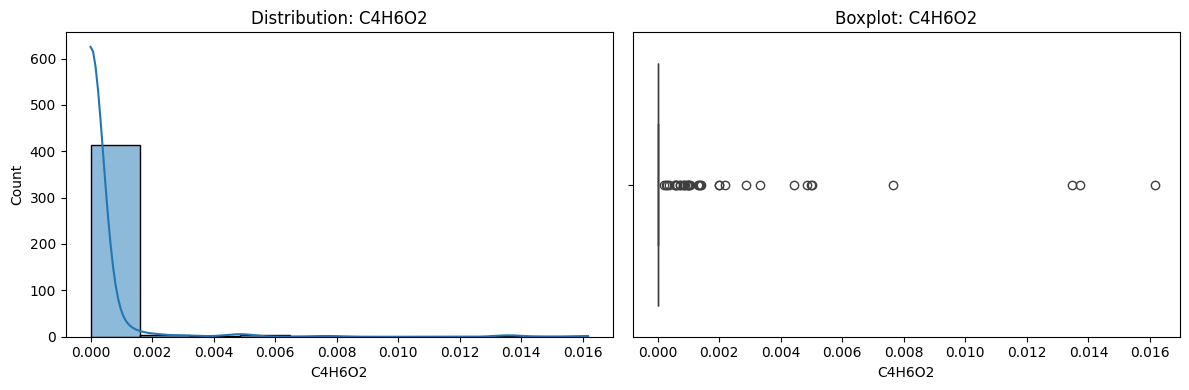

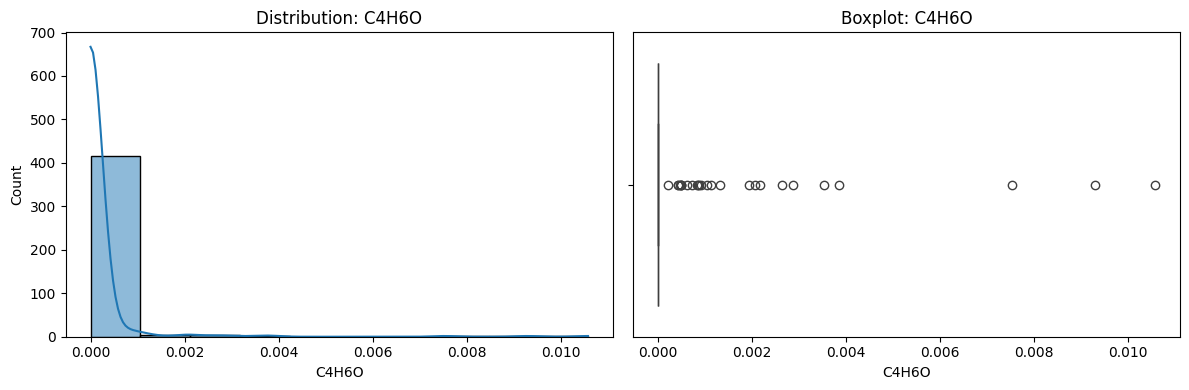

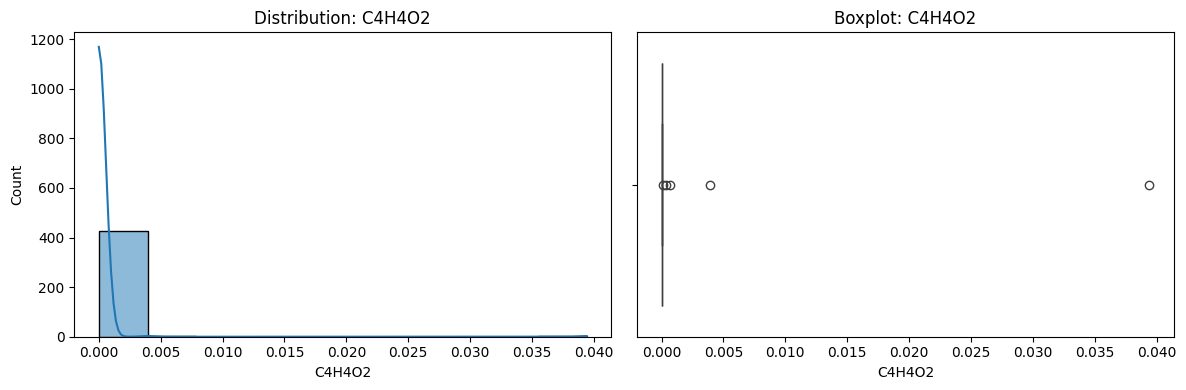

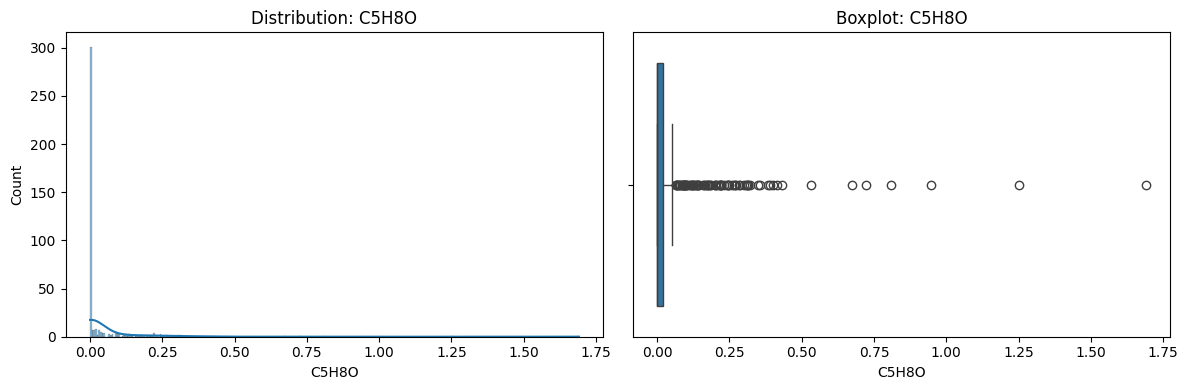

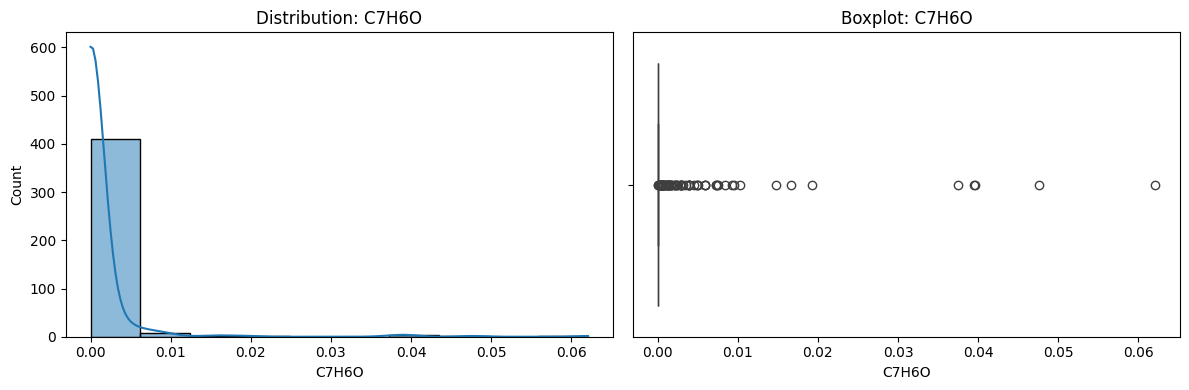

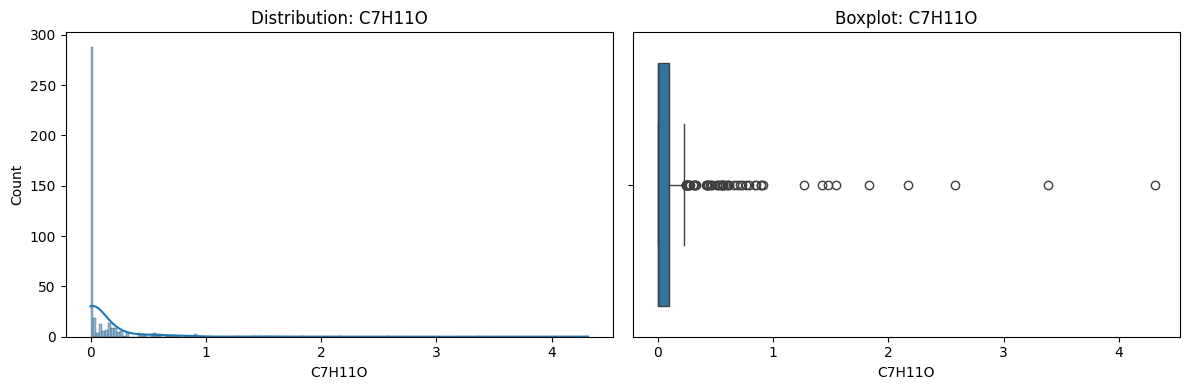

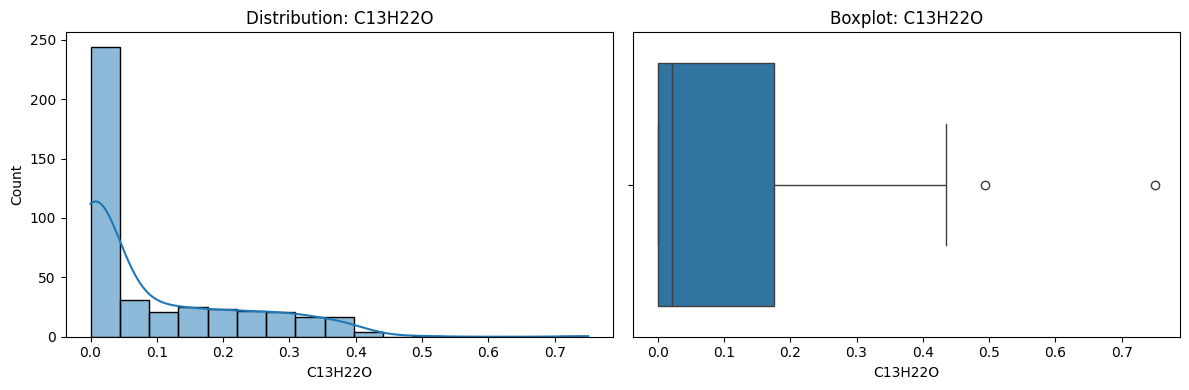

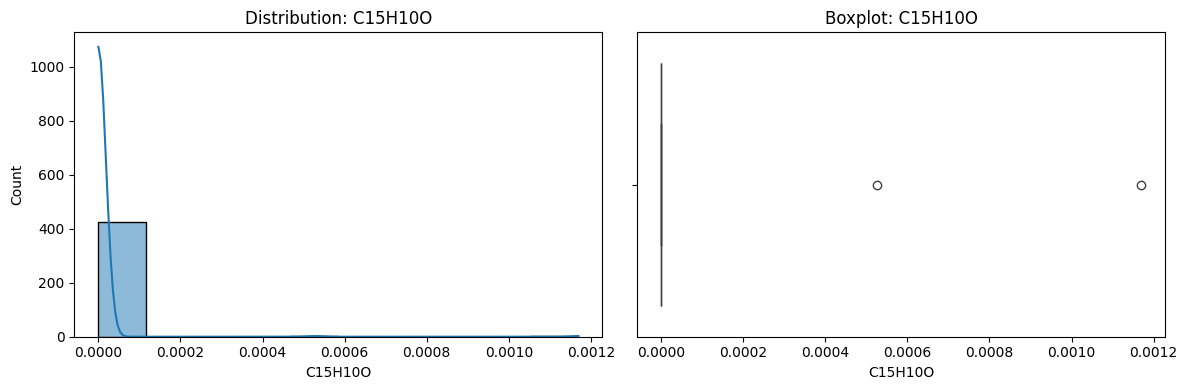

In [13]:
for col in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution: {col}")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")

    plt.tight_layout()
    plt.savefig(EDA_DIR / f"{col}_distribution_boxplot.png", dpi=150)
    plt.show()


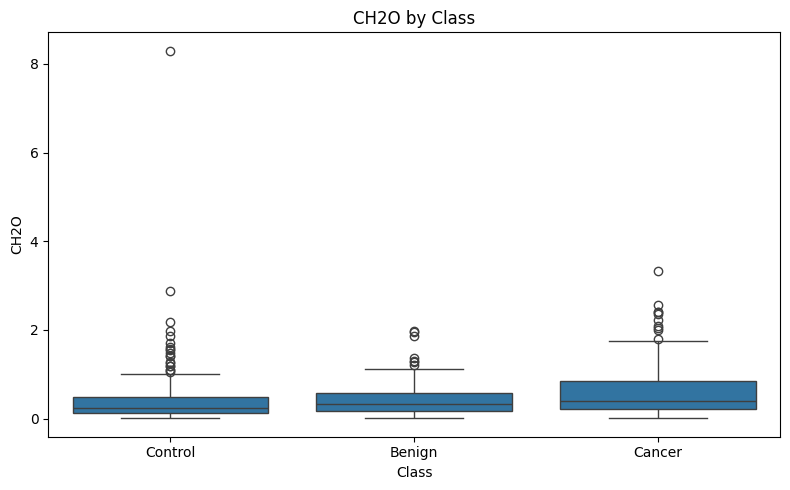

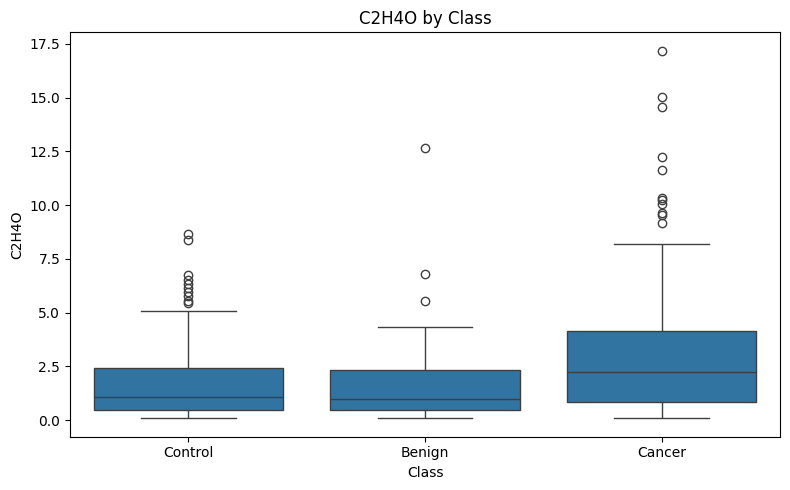

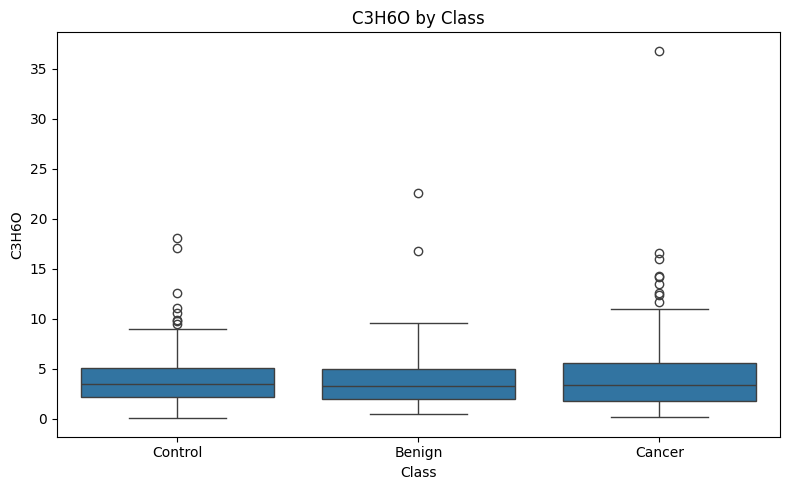

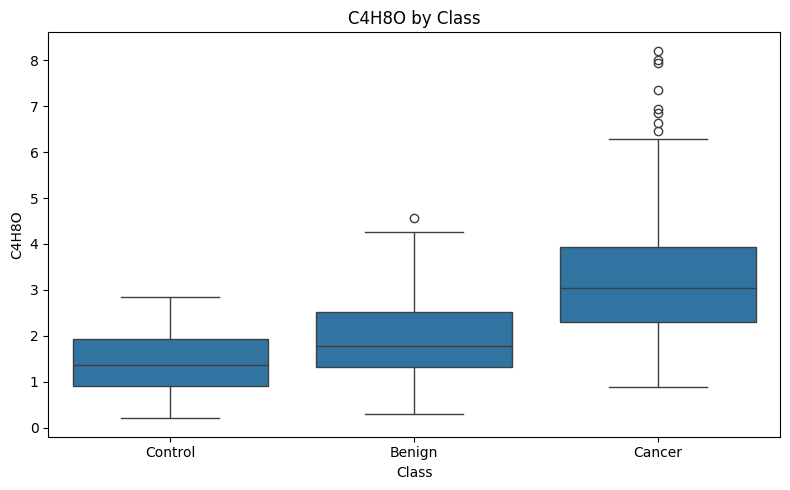

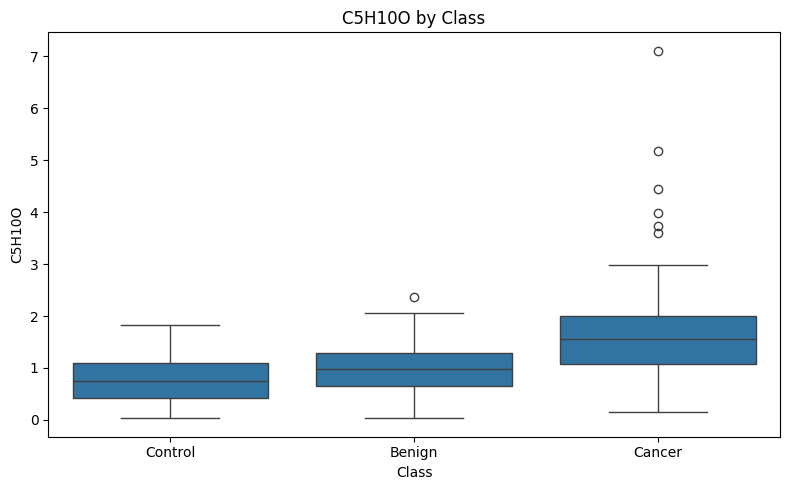

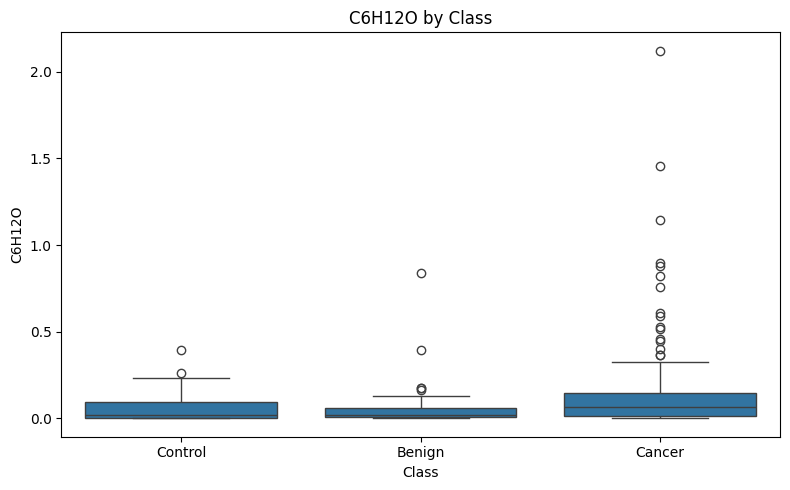

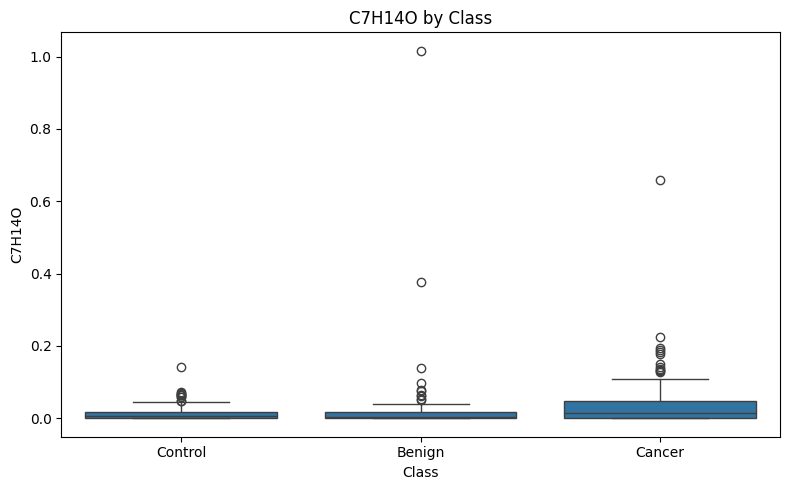

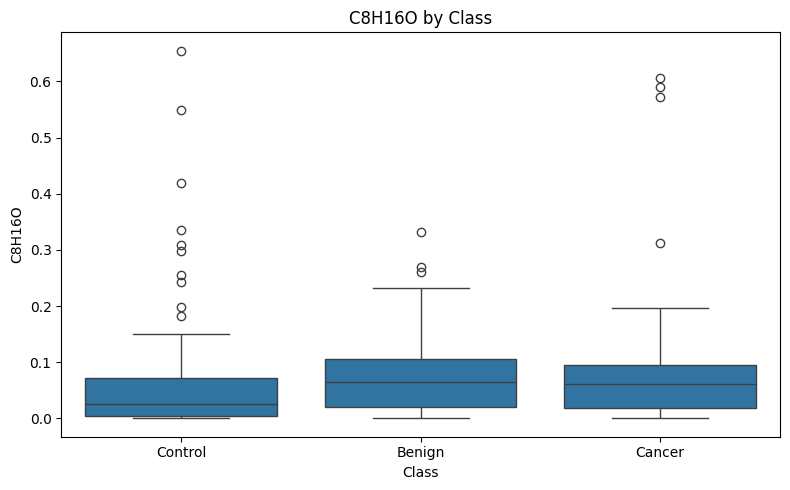

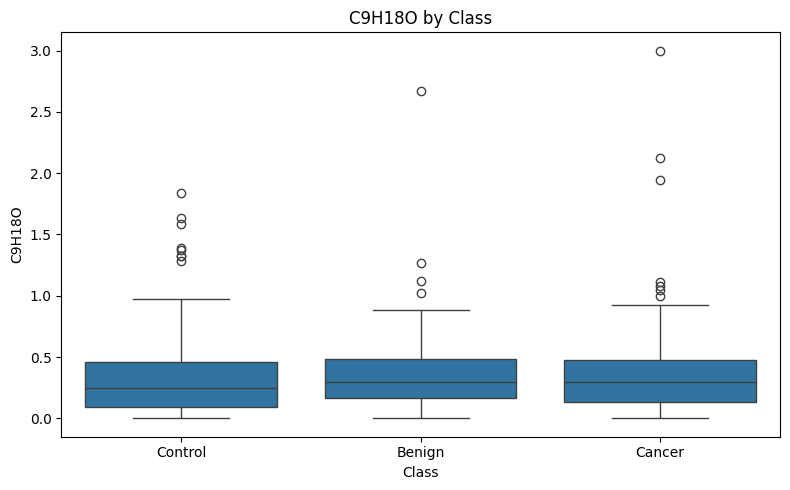

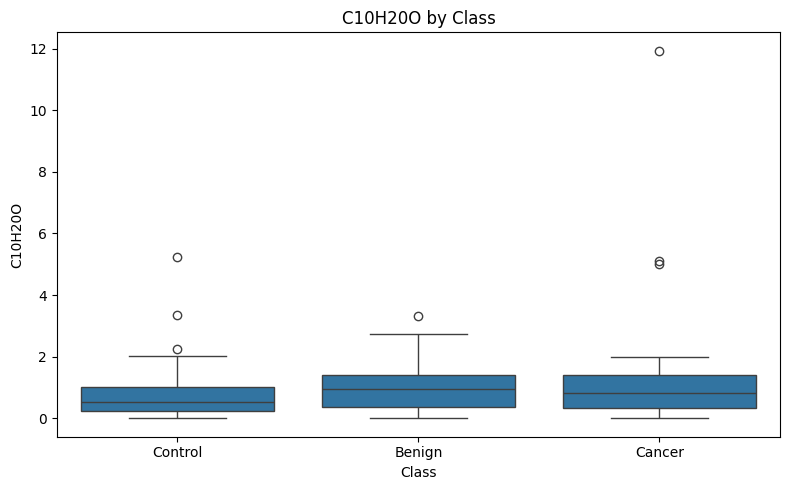

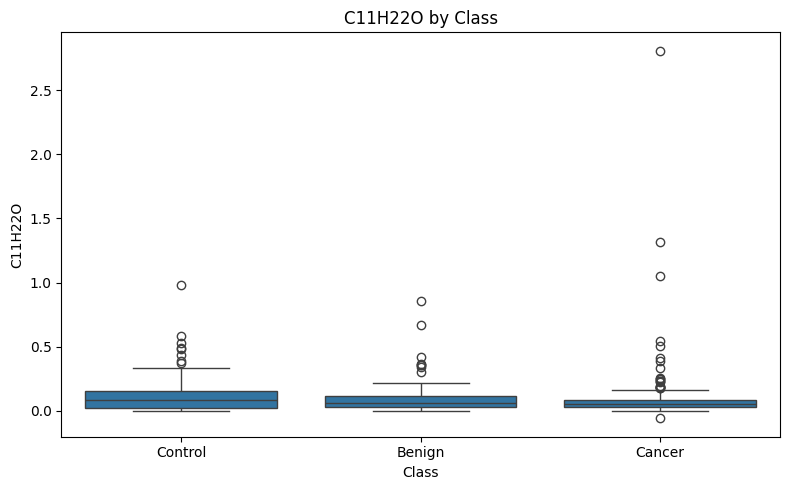

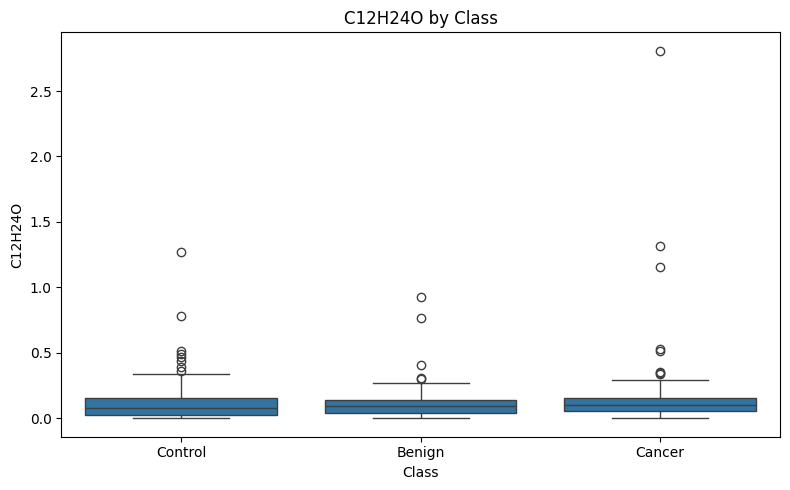

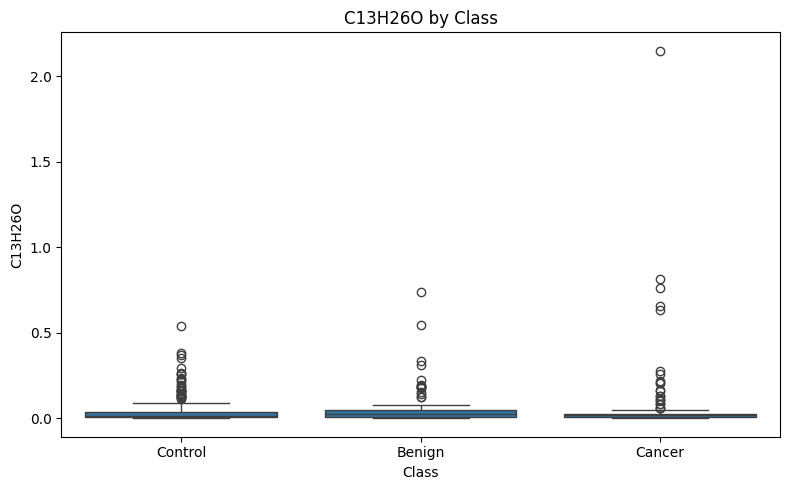

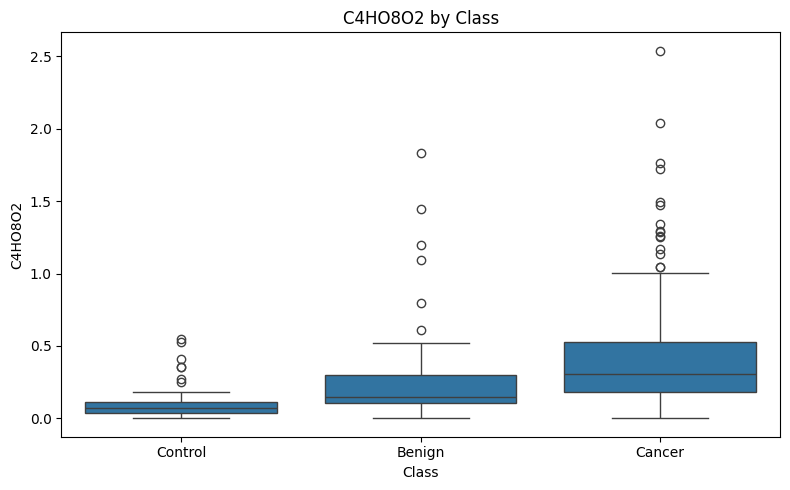

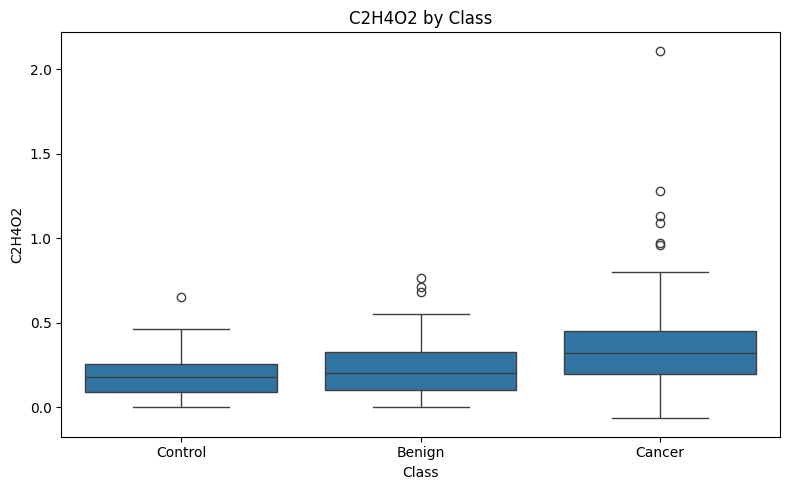

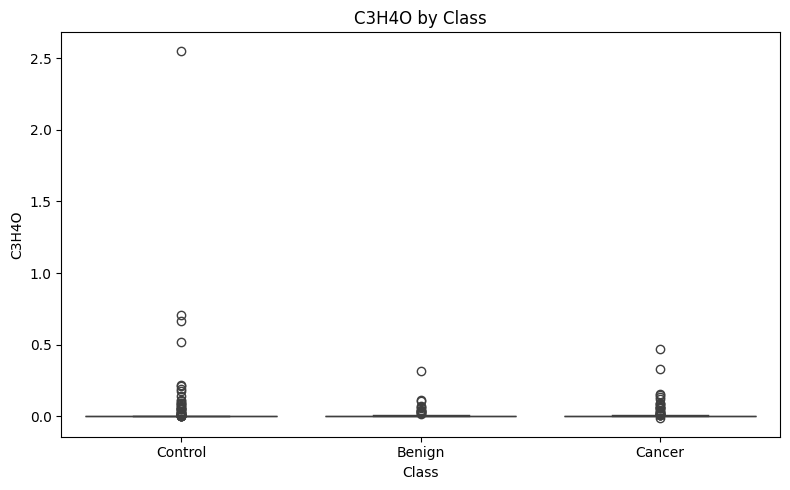

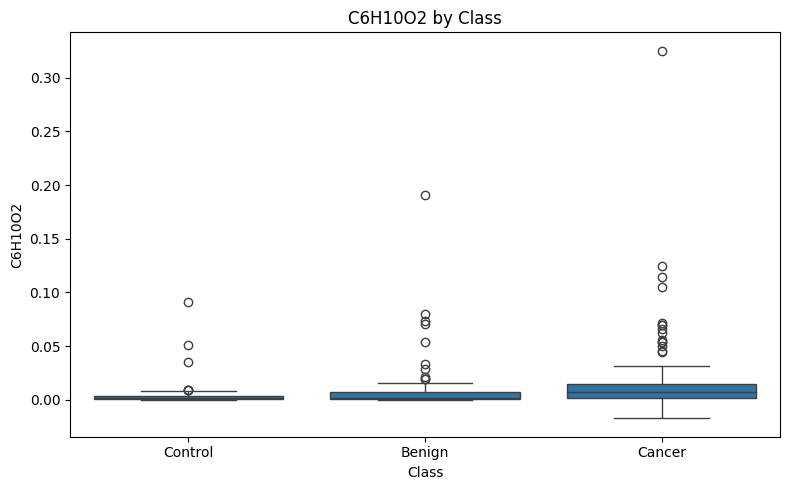

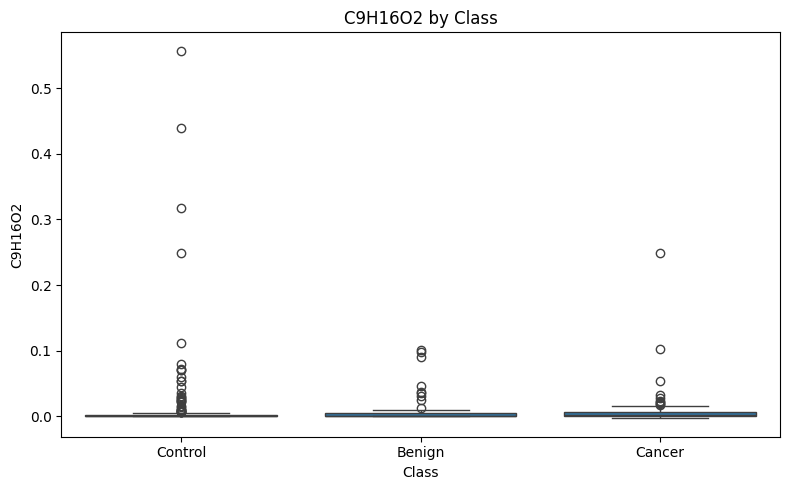

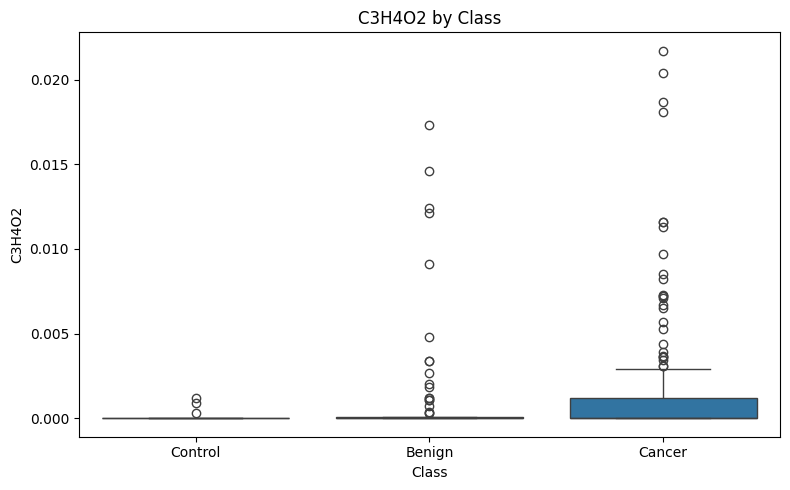

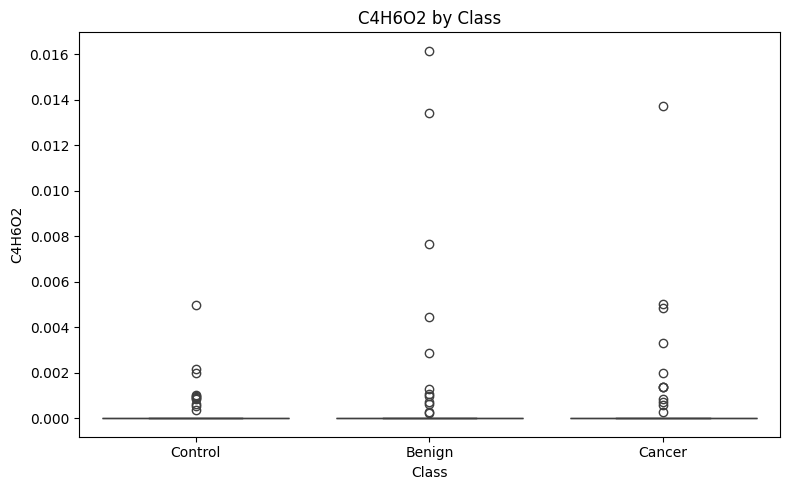

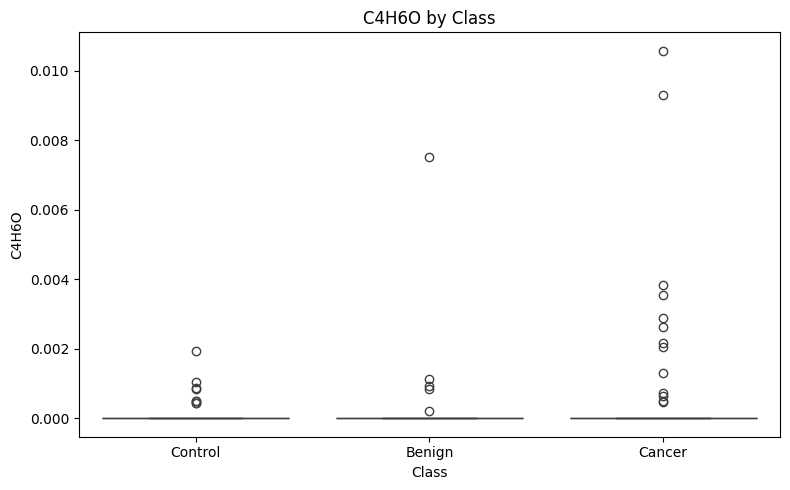

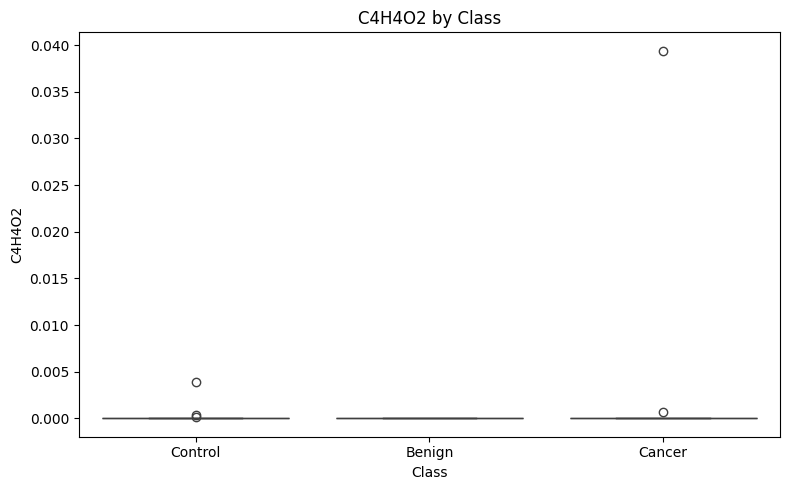

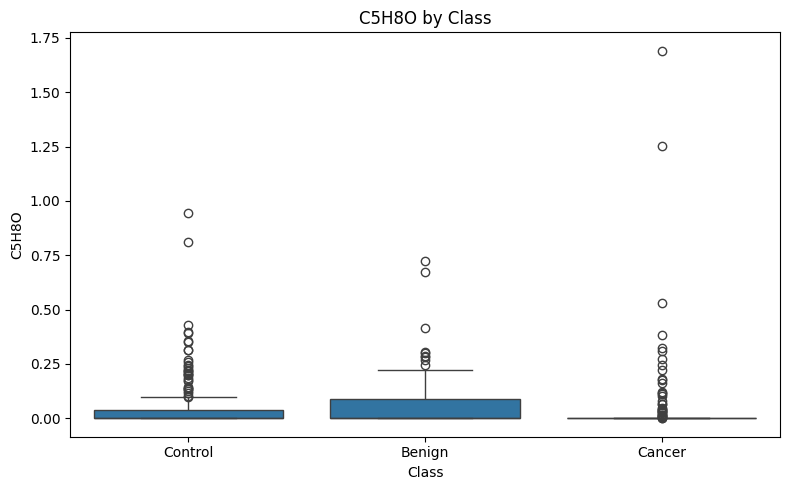

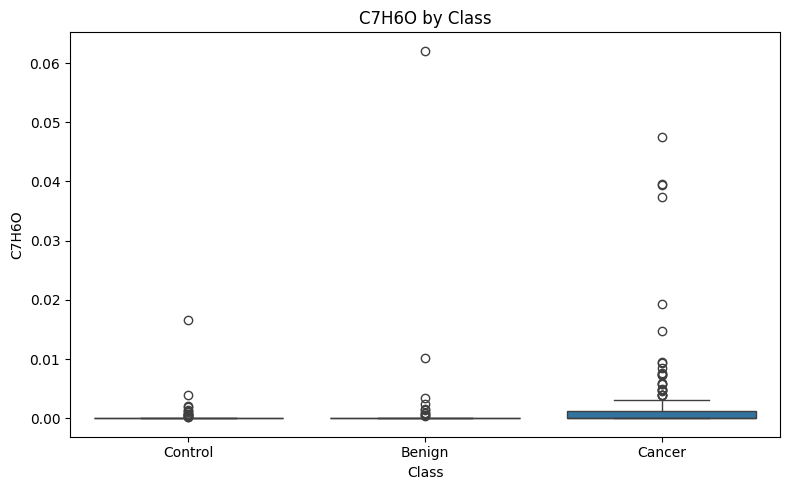

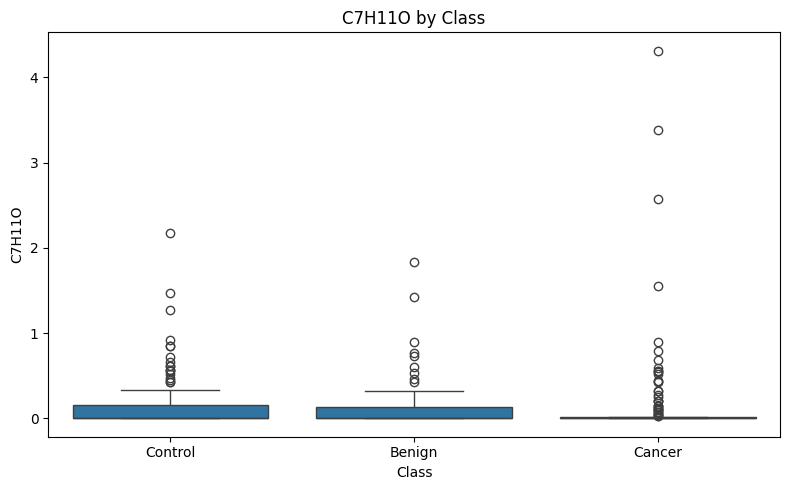

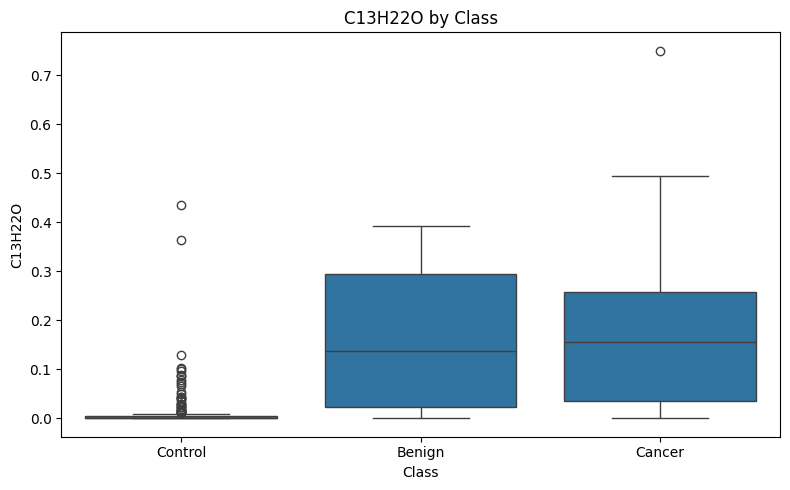

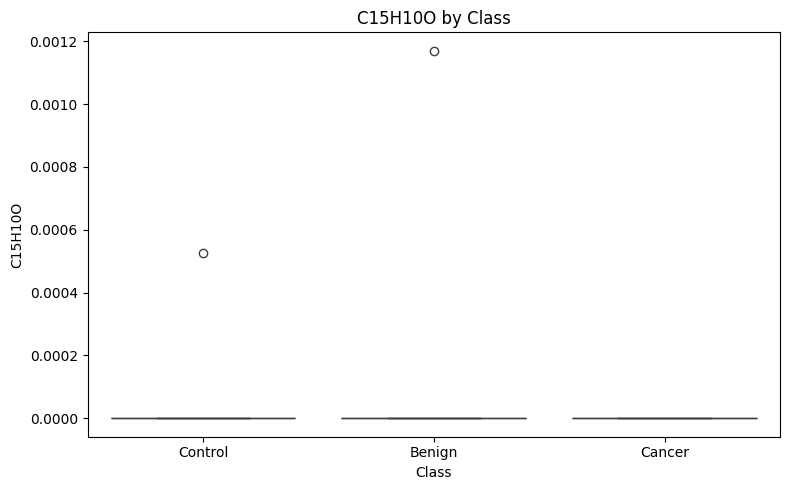

In [14]:
if "Class" in df.columns:
    for col in feature_cols:
        plt.figure(figsize=(8,5))
        sns.boxplot(data=df, x="Class", y=col)
        plt.title(f"{col} by Class")
        plt.tight_layout()
        plt.savefig(EDA_DIR / f"{col}_class_boxplot.png", dpi=150)
        plt.show()


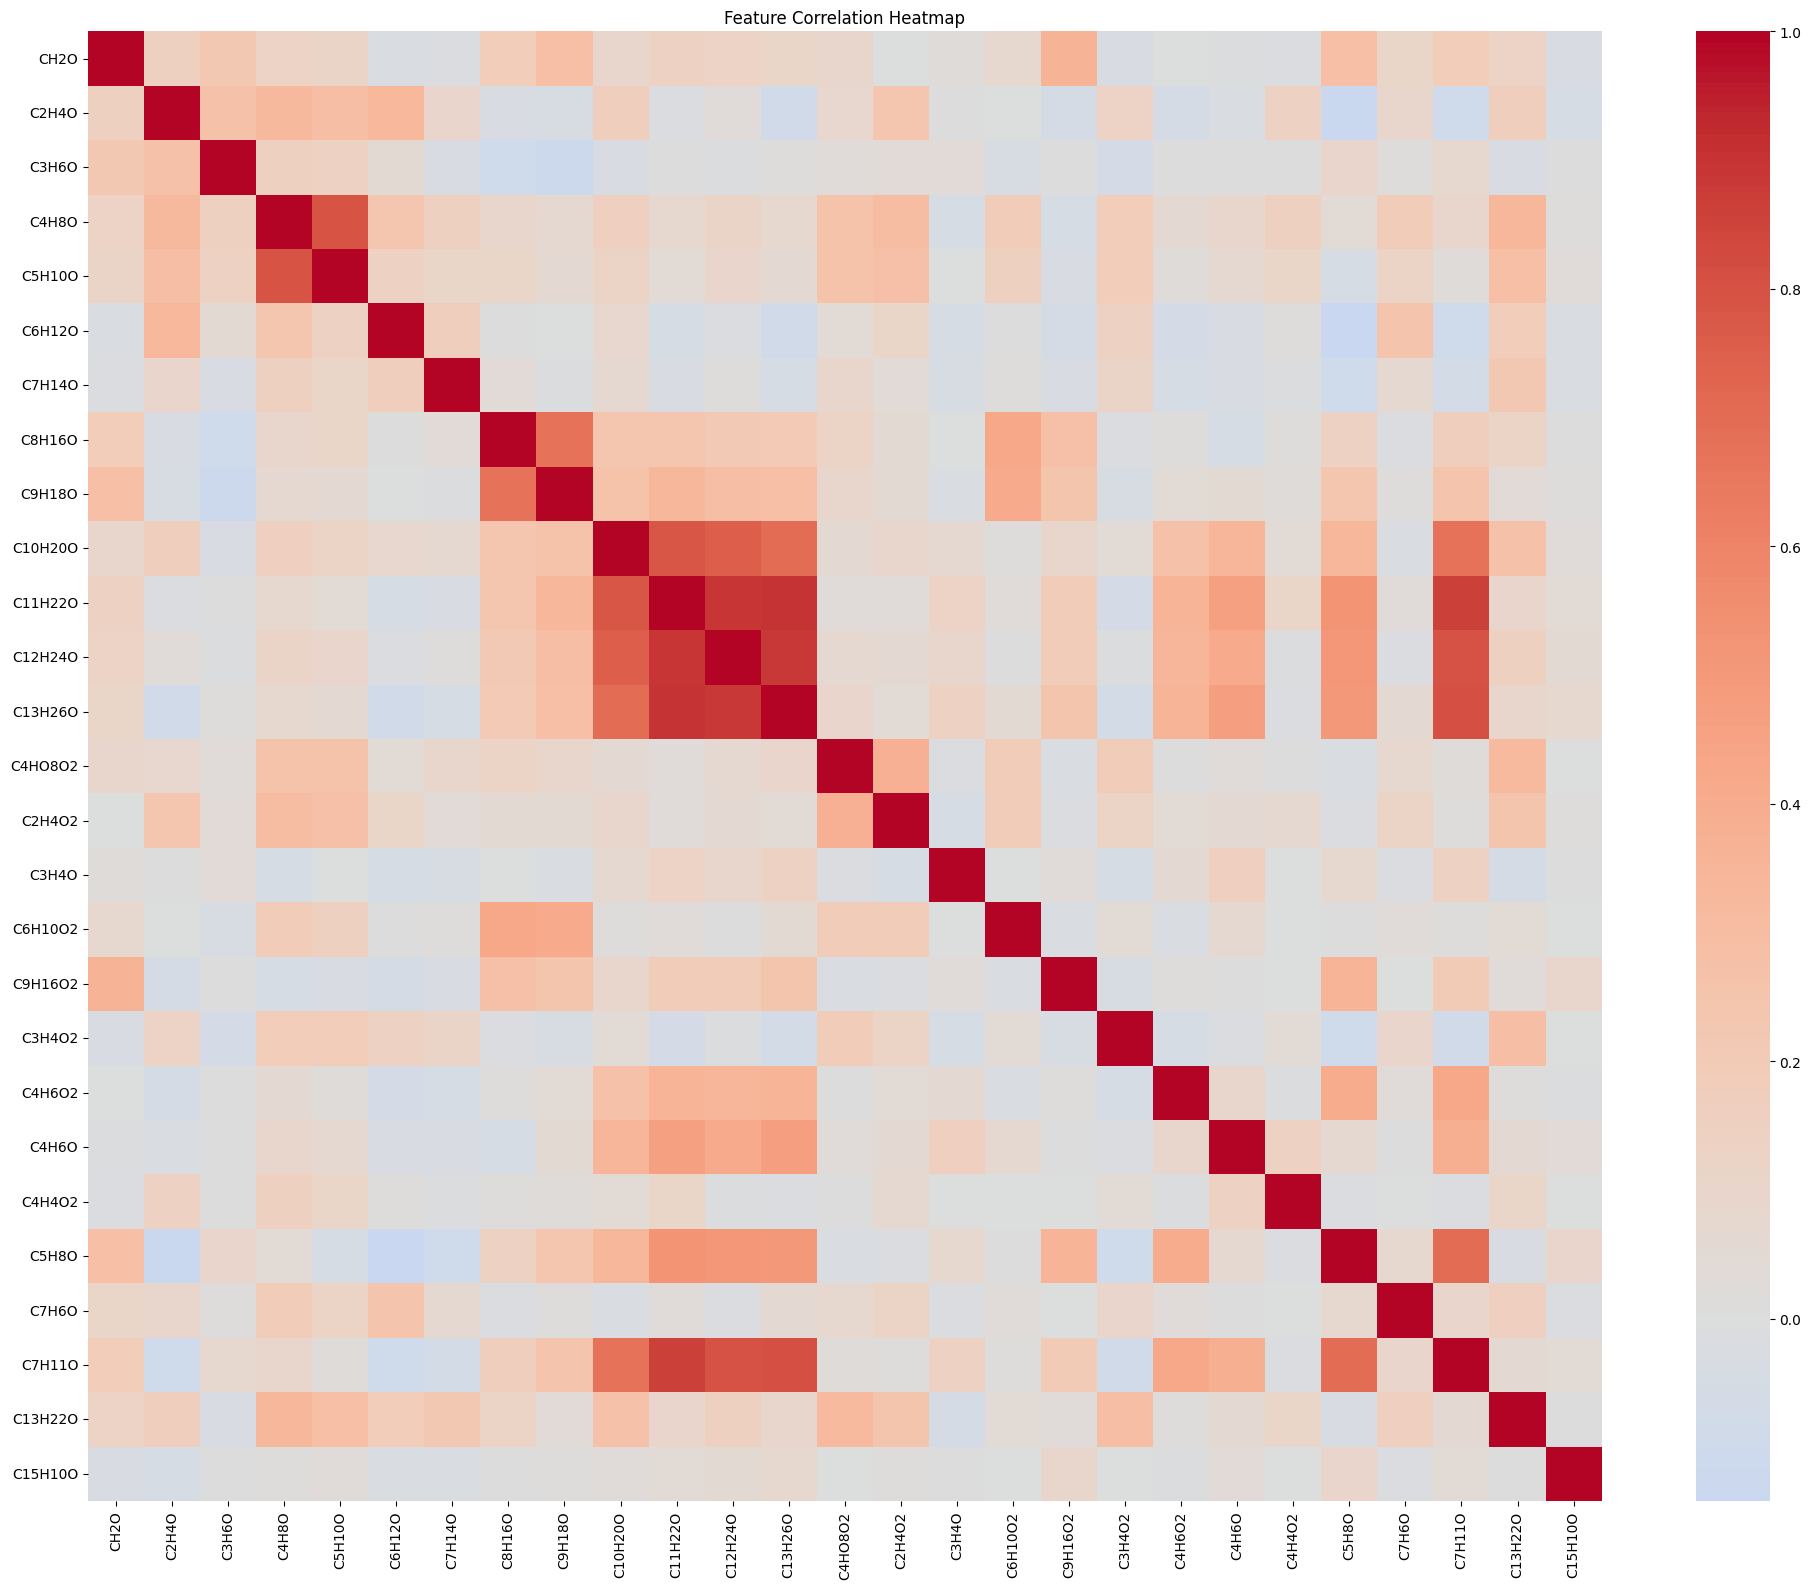

In [15]:
plt.figure(figsize=(20,16))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(EDA_DIR / "correlation_heatmap.png", dpi=200)
plt.show()


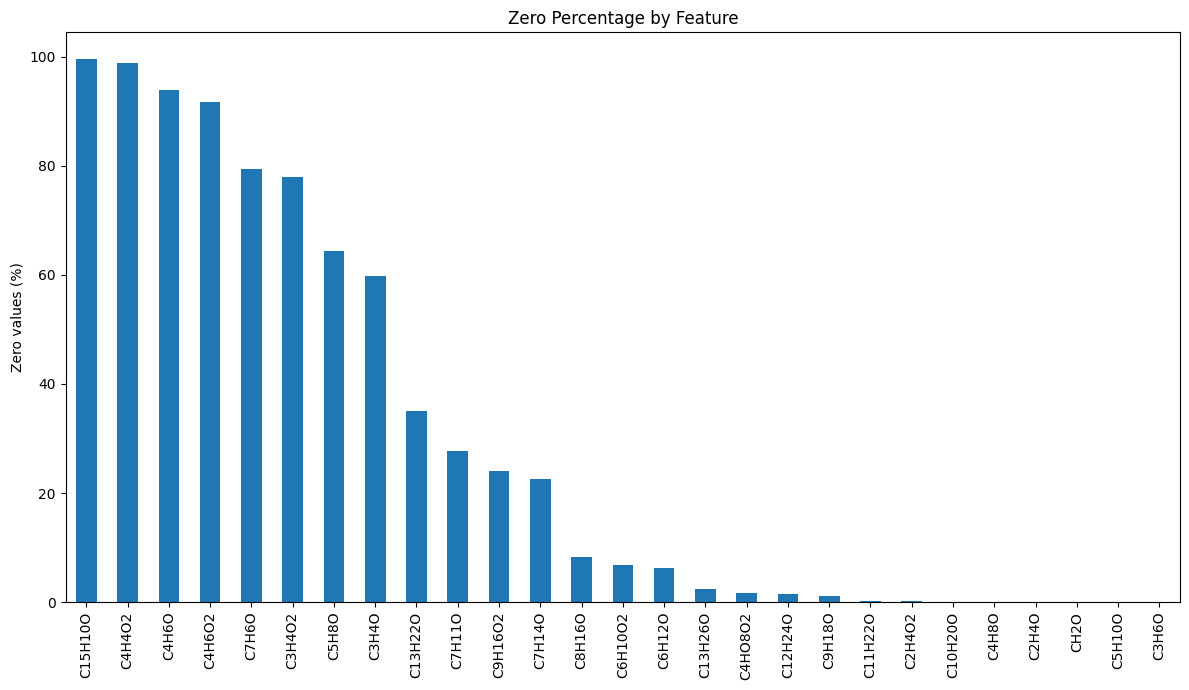

In [16]:
zero_pct = (df[feature_cols].eq(0).mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12,7))
zero_pct.plot(kind="bar")
plt.ylabel("Zero values (%)")
plt.title("Zero Percentage by Feature")
plt.tight_layout()
plt.savefig(EDA_DIR / "zero_percentage.png", dpi=180)
plt.show()


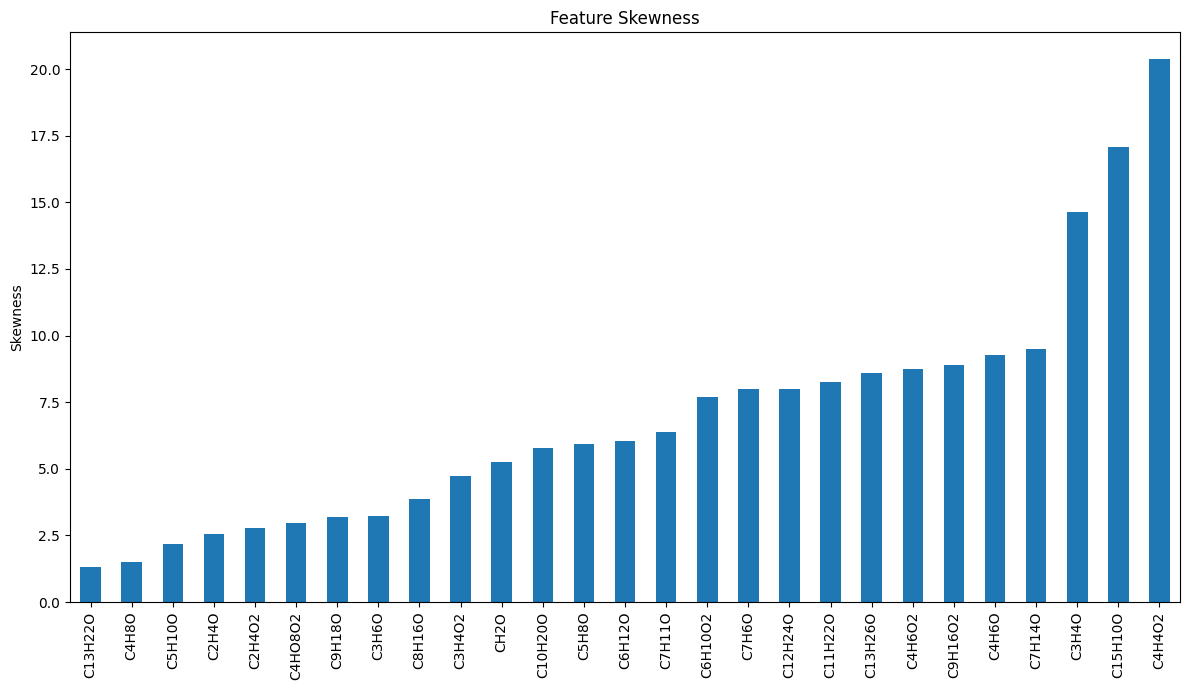

In [17]:
skewness = df[feature_cols].skew().sort_values()

plt.figure(figsize=(12,7))
skewness.plot(kind="bar")
plt.ylabel("Skewness")
plt.title("Feature Skewness")
plt.tight_layout()
plt.savefig(EDA_DIR / "feature_skewness.png", dpi=180)
plt.show()


## 5. Data Quality and Preprocessing Decision

In [18]:
quality_report = pd.DataFrame({
    "missing": df[feature_cols].isna().sum(),
    "missing_pct": df[feature_cols].isna().mean() * 100,
    "unique": df[feature_cols].nunique(),
    "zero_pct": df[feature_cols].eq(0).mean() * 100,
    "skewness": df[feature_cols].skew(),
    "variance": df[feature_cols].var()
})

display(quality_report)

print("Duplicate rows:", df.duplicated().sum())
print("Constant features:", [c for c in feature_cols if df[c].nunique() <= 1])


,missing,missing_pct,unique,zero_pct,skewness,variance
CH2O,0,0.0,352,0.000000,5.264824,4.108610e-01
C2H4O,0,0.0,379,0.000000,2.571248,5.728398e+00
C3H6O,0,0.0,353,0.000000,3.245308,1.226462e+01
C4H8O,0,0.0,289,0.000000,1.486826,1.805756e+00
C5H10O,0,0.0,288,0.000000,2.187699,5.920777e-01
C6H12O,0,0.0,290,6.323185,6.036802,3.232775e-02
C7H14O,0,0.0,244,22.482436,9.480805,4.718229e-03
C8H16O,0,0.0,375,8.196721,3.851644,6.817403e-03
C9H18O,0,0.0,416,1.170960,3.209042,1.193016e-01
C10H20O,0,0.0,427,0.000000,5.762899,7.664458e-01


Duplicate rows: 0
Constant features: []


### Preprocessing Strategy

The notebook does **not** automatically replace zeros, because zero can be a valid VOC measurement.

The preprocessing pipeline:
- drops `PatientID` from predictors,
- performs suitable numeric imputation only when missing values exist,
- uses `PowerTransformer(Yeo-Johnson)` to reduce strong skewness,
- applies `RobustScaler` because VOC measurements can contain extreme values,
- avoids deleting biological extremes by default,
- fits preprocessing on training data only.


In [19]:
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler, StandardScaler, PowerTransformer, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df.drop(columns=["Class"], errors="ignore").copy()
X = X.drop(columns=["PatientID"], errors="ignore")
y = df["Class"].copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()

missing_ratio = X[numeric_features].isna().mean().mean()

if missing_ratio > 0:
    imputer = KNNImputer(n_neighbors=5)
    print("Using KNNImputer because missing values are present.")
else:
    imputer = SimpleImputer(strategy="median")
    print("No missing values detected. Imputer remains in pipeline only for deployment robustness.")

preprocessor = Pipeline([
    ("imputer", imputer),
    ("power", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", RobustScaler())
])

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)


No missing values detected. Imputer remains in pipeline only for deployment robustness.
Classes: ['Benign' 'Cancer' 'Control']


## 6. Train/Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)


(341, 27) (86, 27)


## 7. Feature Engineering and Selection

In [21]:
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif,
    f_classif,
    RFE,
    SelectFromModel
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = X.columns.tolist()

variance_selector = VarianceThreshold(threshold=0.0)
X_var = variance_selector.fit_transform(X_train_processed)

kept_features = np.array(feature_names)[variance_selector.get_support()]
print("Features after VarianceThreshold:", len(kept_features))

mi = mutual_info_classif(X_train_processed, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"feature": feature_names, "mutual_information": mi})
mi_df = mi_df.sort_values("mutual_information", ascending=False)
mi_df.to_csv(OUTPUT_DIR / "mutual_information_ranking.csv", index=False)
display(mi_df)


Features after VarianceThreshold: 27


,feature,mutual_information
3,C4H8O,0.311480
25,C13H22O,0.304831
13,C4HO8O2,0.274242
24,C7H11O,0.274227
4,C5H10O,0.181845
18,C3H4O2,0.112385
16,C6H10O2,0.109159
10,C11H22O,0.103972
14,C2H4O2,0.097189
17,C9H16O2,0.084793


In [22]:
rf_selector_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)
rf_selector_model.fit(X_train_processed, y_train)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_selector_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.to_csv(OUTPUT_DIR / "rf_feature_importance.csv", index=False)
display(importance_df)


,feature,importance
25,C13H22O,0.142628
13,C4HO8O2,0.104732
3,C4H8O,0.098901
4,C5H10O,0.062738
24,C7H11O,0.049997
14,C2H4O2,0.049456
16,C6H10O2,0.041899
7,C8H16O,0.036844
9,C10H20O,0.034148
1,C2H4O,0.033953


,component,explained_variance_ratio,cumulative_variance
0,1,5.401975e-01,0.540198
1,2,1.201790e-01,0.660377
2,3,8.884748e-02,0.749224
3,4,3.885808e-02,0.788082
4,5,3.136463e-02,0.819447
5,6,2.975575e-02,0.849202
6,7,2.346411e-02,0.872667
7,8,1.835863e-02,0.891025
8,9,1.733485e-02,0.908360
9,10,1.280490e-02,0.921165


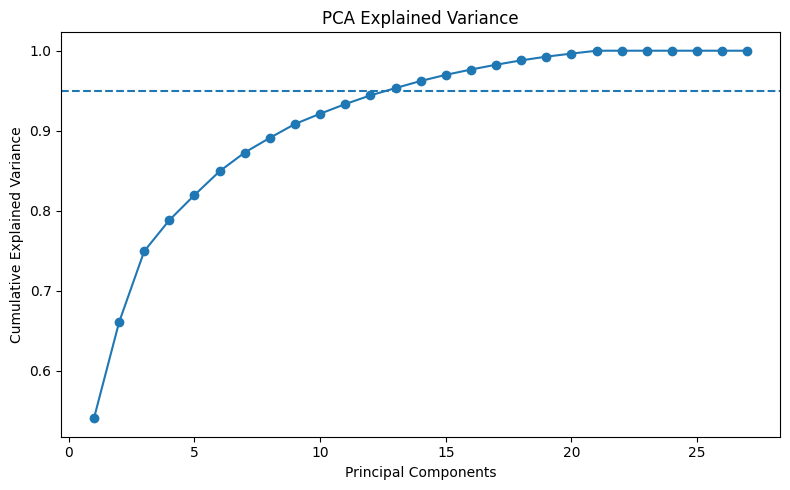

In [23]:
pca = PCA()
pca.fit(X_train_processed)

pca_df = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

display(pca_df)
pca_df.to_csv(OUTPUT_DIR / "pca_explained_variance.csv", index=False)

plt.figure(figsize=(8,5))
plt.plot(pca_df["component"], pca_df["cumulative_variance"], marker="o")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.tight_layout()
plt.show()


## 8. Classification Models — 20+ Models

In [24]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neural_network import MLPClassifier

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE),
    "Ridge Classifier": RidgeClassifier(),
    "SGD Classifier": SGDClassifier(loss="log_loss", class_weight="balanced", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "Bernoulli NB": BernoulliNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "Linear SVM": SVC(kernel="linear", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "RBF SVM": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Bagging": BaggingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(n_estimators=150, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,50), max_iter=2000, random_state=RANDOM_STATE)
}

try:
    from xgboost import XGBClassifier
    classifiers["XGBoost"] = XGBClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        eval_metric="mlogloss"
    )
except Exception as e:
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMClassifier
    classifiers["LightGBM"] = LGBMClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        verbose=-1
    )
except Exception as e:
    print("LightGBM unavailable:", e)

try:
    from catboost import CatBoostClassifier
    classifiers["CatBoost"] = CatBoostClassifier(
        iterations=300,
        random_state=RANDOM_STATE,
        verbose=0
    )
except Exception as e:
    print("CatBoost unavailable:", e)

print("Total classifiers:", len(classifiers))
print(list(classifiers.keys()))


CatBoost unavailable: No module named 'catboost'
Total classifiers: 20
['Logistic Regression', 'Ridge Classifier', 'SGD Classifier', 'KNN', 'Gaussian NB', 'Bernoulli NB', 'LDA', 'QDA', 'Linear SVM', 'RBF SVM', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Bagging', 'AdaBoost', 'Gradient Boosting', 'Hist Gradient Boosting', 'MLP', 'XGBoost', 'LightGBM']


## 9. Classification Metrics

In [25]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report
)

classification_results = []
trained_classifiers = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in classifiers.items():
    print("Training:", name)

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    try:
        start = time.time()
        pipe.fit(X_train, y_train)
        train_time = time.time() - start

        start = time.time()
        pred = pipe.predict(X_test)
        inference_time = time.time() - start

        result = {
            "Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
            "Precision Macro": precision_score(y_test, pred, average="macro", zero_division=0),
            "Precision Weighted": precision_score(y_test, pred, average="weighted", zero_division=0),
            "Recall Macro": recall_score(y_test, pred, average="macro", zero_division=0),
            "Recall Weighted": recall_score(y_test, pred, average="weighted", zero_division=0),
            "F1 Macro": f1_score(y_test, pred, average="macro", zero_division=0),
            "F1 Weighted": f1_score(y_test, pred, average="weighted", zero_division=0),
            "MCC": matthews_corrcoef(y_test, pred),
            "Cohen Kappa": cohen_kappa_score(y_test, pred),
            "Train Time": train_time,
            "Inference Time": inference_time
        }

        if hasattr(pipe, "predict_proba"):
            try:
                prob = pipe.predict_proba(X_test)
                result["ROC AUC OvR Macro"] = roc_auc_score(
                    y_test, prob, multi_class="ovr", average="macro"
                )
                result["ROC AUC OvR Weighted"] = roc_auc_score(
                    y_test, prob, multi_class="ovr", average="weighted"
                )
                result["Log Loss"] = log_loss(y_test, prob)
            except:
                result["ROC AUC OvR Macro"] = np.nan
                result["ROC AUC OvR Weighted"] = np.nan
                result["Log Loss"] = np.nan
        else:
            result["ROC AUC OvR Macro"] = np.nan
            result["ROC AUC OvR Weighted"] = np.nan
            result["Log Loss"] = np.nan

        classification_results.append(result)
        trained_classifiers[name] = pipe

    except Exception as e:
        print(f"{name} failed:", e)

classification_results_df = pd.DataFrame(classification_results)
classification_results_df = classification_results_df.sort_values(
    ["F1 Macro", "MCC", "Balanced Accuracy"],
    ascending=False
)

classification_results_df.to_csv(CLASS_DIR / "classification_model_comparison.csv", index=False)
display(classification_results_df)


Training: Logistic Regression
Training: Ridge Classifier
Training: SGD Classifier
Training: KNN
Training: Gaussian NB
Training: Bernoulli NB
Training: LDA
Training: QDA
Training: Linear SVM
Training: RBF SVM
Training: Decision Tree
Training: Random Forest
Training: Extra Trees
Training: Bagging
Training: AdaBoost
Training: Gradient Boosting
Training: Hist Gradient Boosting
Training: MLP
Training: XGBoost
Training: LightGBM


,Model,Accuracy,Balanced Accuracy,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1 Macro,F1 Weighted,MCC,Cohen Kappa,Train Time,Inference Time,ROC AUC OvR Macro,ROC AUC OvR Weighted,Log Loss
13,Bagging,0.802326,0.712340,0.755342,0.792673,0.712340,0.802326,0.716373,0.786774,0.683527,0.675616,0.609946,0.016852,0.905966,0.931004,0.482975
9,RBF SVM,0.767442,0.718376,0.719981,0.789654,0.718376,0.767442,0.714969,0.775144,0.635900,0.633028,0.082545,0.006878,0.863479,0.899697,0.575295
0,Logistic Regression,0.767442,0.718376,0.714609,0.780807,0.718376,0.767442,0.714510,0.772710,0.633488,0.632243,0.098720,0.004908,0.858703,0.893156,0.600185
10,Decision Tree,0.767442,0.706571,0.714286,0.764396,0.706571,0.767442,0.709572,0.764983,0.626094,0.625109,0.066881,0.003310,0.793052,0.819302,8.382245
15,Gradient Boosting,0.790698,0.703793,0.746053,0.778442,0.703793,0.790698,0.708038,0.774484,0.662806,0.656000,1.175556,0.005160,0.908406,0.932681,0.531160
6,LDA,0.779070,0.701442,0.717172,0.768323,0.701442,0.779070,0.706122,0.770982,0.642952,0.640088,0.063075,0.004070,0.873677,0.903617,0.611866
14,AdaBoost,0.779070,0.703312,0.711194,0.770486,0.703312,0.779070,0.706055,0.773779,0.643574,0.642529,0.461739,0.029221,0.828895,0.882971,1.038384
8,Linear SVM,0.779070,0.703312,0.706775,0.779372,0.703312,0.779070,0.704570,0.778648,0.646272,0.645707,0.096689,0.003411,0.846672,0.886557,0.599223
19,LightGBM,0.802326,0.698665,0.720899,0.775655,0.698665,0.802326,0.696552,0.781142,0.680242,0.674097,0.401889,0.009098,0.898415,0.926347,1.053477
5,Bernoulli NB,0.779070,0.691506,0.702020,0.761628,0.691506,0.779070,0.693194,0.768111,0.641852,0.639850,0.056803,0.003616,0.871472,0.895388,0.684709


## 10. Best Classifier

Best classifier: Bagging
              precision    recall  f1-score   support

      Benign       0.62      0.33      0.43        15
      Cancer       0.74      0.91      0.82        32
     Control       0.90      0.90      0.90        39

    accuracy                           0.80        86
   macro avg       0.76      0.71      0.72        86
weighted avg       0.79      0.80      0.79        86



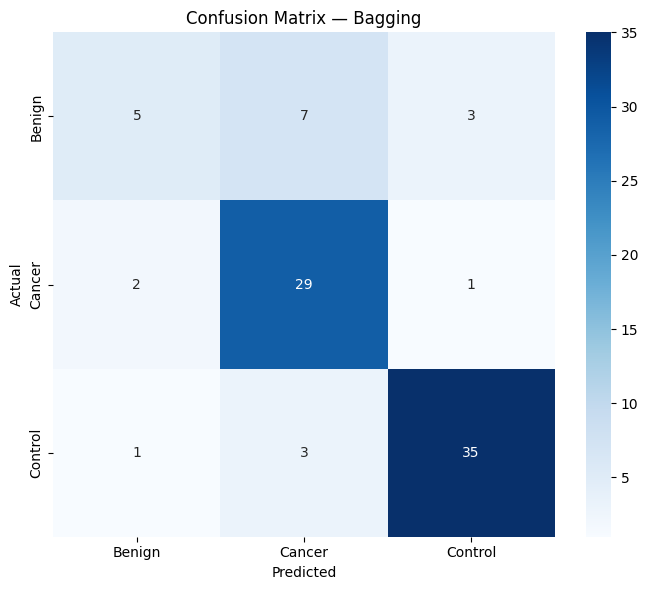

In [26]:
best_classifier_name = classification_results_df.iloc[0]["Model"]
best_classifier = trained_classifiers[best_classifier_name]

print("Best classifier:", best_classifier_name)

best_pred = best_classifier.predict(X_test)

print(classification_report(
    y_test,
    best_pred,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_classifier_name}")
plt.tight_layout()
plt.savefig(CLASS_DIR / "best_classifier_confusion_matrix.png", dpi=200)
plt.show()


## 11. ROC Curve

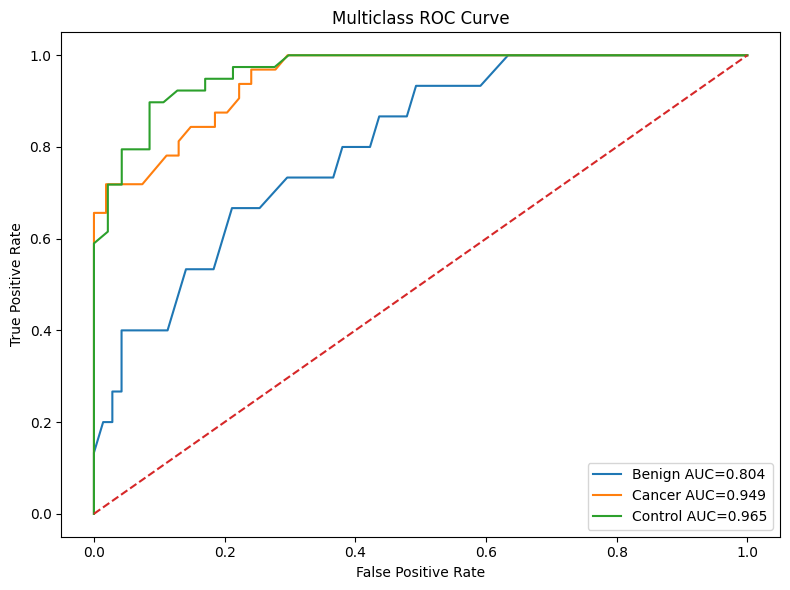

In [27]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

if hasattr(best_classifier, "predict_proba"):
    probabilities = best_classifier.predict_proba(X_test)
    y_bin = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))

    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(label_encoder.classes_):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probabilities[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} AUC={roc_auc:.3f}")

    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(CLASS_DIR / "multiclass_roc_curve.png", dpi=200)
    plt.show()


## 12. Regression Task — VOC Concentration Prediction

In [28]:
REGRESSION_TARGET = "CH2O"

if REGRESSION_TARGET not in df.columns:
    REGRESSION_TARGET = feature_cols[0]

X_reg = df.drop(columns=[REGRESSION_TARGET, "PatientID", "Class"], errors="ignore")
y_reg = df[REGRESSION_TARGET].astype(float)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Regression target:", REGRESSION_TARGET)
print("Predictors:", X_reg.shape[1])


Regression target: CH2O
Predictors: 26


## 13. Regression Models — 15+ Models

In [29]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    BaggingRegressor
)
from sklearn.neural_network import MLPRegressor

regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Huber": HuberRegressor(max_iter=2000),
    "SGD Regressor": SGDRegressor(max_iter=5000, random_state=RANDOM_STATE),
    "KNN Regressor": KNeighborsRegressor(),
    "Linear SVR": LinearSVR(max_iter=10000, random_state=RANDOM_STATE),
    "RBF SVR": SVR(kernel="rbf"),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Bagging": BaggingRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostRegressor(n_estimators=150, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "MLP Regressor": MLPRegressor(hidden_layer_sizes=(100,50), max_iter=3000, random_state=RANDOM_STATE)
}

try:
    from xgboost import XGBRegressor
    regressors["XGBoost"] = XGBRegressor(n_estimators=300, random_state=RANDOM_STATE)
except Exception as e:
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMRegressor
    regressors["LightGBM"] = LGBMRegressor(n_estimators=300, random_state=RANDOM_STATE, verbose=-1)
except Exception as e:
    print("LightGBM unavailable:", e)

try:
    from catboost import CatBoostRegressor
    regressors["CatBoost"] = CatBoostRegressor(iterations=300, random_state=RANDOM_STATE, verbose=0)
except Exception as e:
    print("CatBoost unavailable:", e)

print("Total regressors:", len(regressors))
print(list(regressors.keys()))


CatBoost unavailable: No module named 'catboost'
Total regressors: 19
['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'Huber', 'SGD Regressor', 'KNN Regressor', 'Linear SVR', 'RBF SVR', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Bagging', 'AdaBoost', 'Gradient Boosting', 'Hist Gradient Boosting', 'MLP Regressor', 'XGBoost', 'LightGBM']


## 14. Regression Metrics

In [30]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    explained_variance_score,
    max_error
)

reg_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", RobustScaler())
])

regression_results = []
trained_regressors = {}

def adjusted_r2(r2, n, p):
    if n <= p + 1:
        return np.nan
    return 1 - (1-r2)*(n-1)/(n-p-1)

for name, model in regressors.items():
    print("Training:", name)

    pipe = Pipeline([
        ("preprocessor", reg_preprocessor),
        ("model", model)
    ])

    try:
        start = time.time()
        pipe.fit(Xr_train, yr_train)
        train_time = time.time() - start

        start = time.time()
        pred = pipe.predict(Xr_test)
        inference_time = time.time() - start

        mse = mean_squared_error(yr_test, pred)
        r2 = r2_score(yr_test, pred)

        result = {
            "Model": name,
            "MAE": mean_absolute_error(yr_test, pred),
            "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R2": r2,
            "Adjusted R2": adjusted_r2(r2, len(yr_test), Xr_test.shape[1]),
            "Median Absolute Error": median_absolute_error(yr_test, pred),
            "Explained Variance": explained_variance_score(yr_test, pred),
            "Max Error": max_error(yr_test, pred),
            "Train Time": train_time,
            "Inference Time": inference_time
        }

        regression_results.append(result)
        trained_regressors[name] = pipe

    except Exception as e:
        print(f"{name} failed:", e)

regression_results_df = pd.DataFrame(regression_results)
regression_results_df = regression_results_df.sort_values(
    ["RMSE", "MAE"],
    ascending=True
)

regression_results_df.to_csv(REG_DIR / "regression_model_comparison.csv", index=False)
display(regression_results_df)


Training: Linear Regression
Training: Ridge
Training: Lasso
Training: ElasticNet
Training: Huber
Training: SGD Regressor
Training: KNN Regressor
Training: Linear SVR
Training: RBF SVR
Training: Decision Tree
Training: Random Forest
Training: Extra Trees
Training: Bagging
Training: AdaBoost
Training: Gradient Boosting
Training: Hist Gradient Boosting
Training: MLP Regressor
Training: XGBoost
Training: LightGBM


,Model,MAE,MSE,RMSE,R2,Adjusted R2,Median Absolute Error,Explained Variance,Max Error,Train Time,Inference Time
16,MLP Regressor,0.436551,0.753821,0.868229,0.145809,-0.230614,0.317877,0.149039,6.836833,0.790912,0.004747
0,Linear Regression,0.388769,0.776412,0.881142,0.120211,-0.267493,0.261140,0.120566,7.293298,0.055372,0.004310
5,SGD Regressor,0.378612,0.776912,0.881426,0.119644,-0.268309,0.233982,0.122444,7.319344,0.085580,0.003828
8,RBF SVR,0.322709,0.776963,0.881455,0.119586,-0.268393,0.150450,0.143140,7.441206,0.056430,0.003925
1,Ridge,0.385458,0.781773,0.884179,0.114136,-0.276245,0.252534,0.115102,7.333326,0.078223,0.004157
15,Hist Gradient Boosting,0.319934,0.788223,0.887819,0.106827,-0.286775,0.151418,0.113720,7.505184,0.178085,0.004612
6,KNN Regressor,0.355455,0.802942,0.896070,0.090148,-0.310803,0.194506,0.095765,7.502600,0.058836,0.003577
12,Bagging,0.354221,0.804434,0.896902,0.088458,-0.313239,0.172331,0.089426,7.390686,0.852188,0.019723
11,Extra Trees,0.350210,0.806990,0.898326,0.085562,-0.317411,0.185993,0.086893,7.555287,0.889058,0.028930
14,Gradient Boosting,0.338911,0.808038,0.898909,0.084374,-0.319123,0.152366,0.086494,7.446151,0.384097,0.004049


## 15. Best Regressor

Best regressor: MLP Regressor


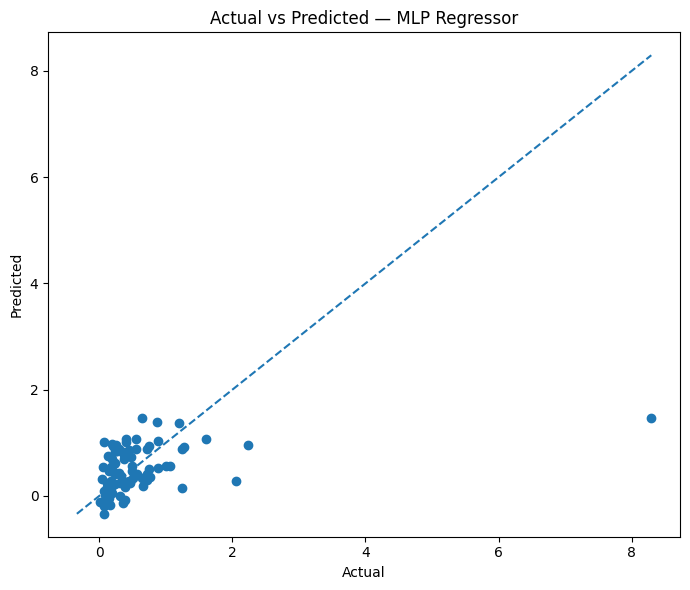

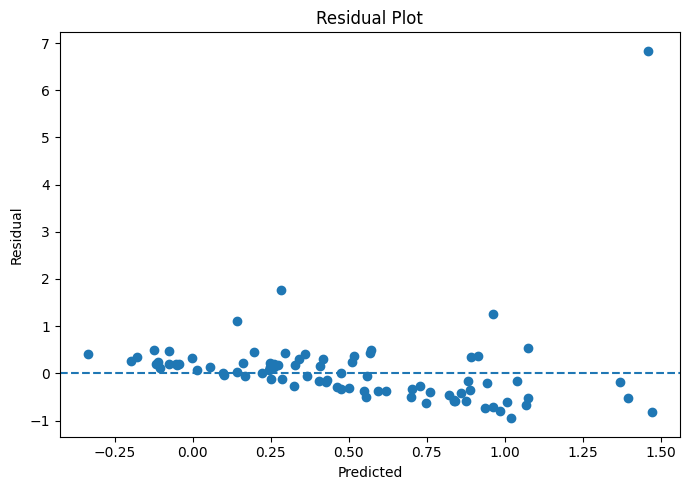

In [31]:
best_regressor_name = regression_results_df.iloc[0]["Model"]
best_regressor = trained_regressors[best_regressor_name]

reg_pred = best_regressor.predict(Xr_test)

print("Best regressor:", best_regressor_name)

plt.figure(figsize=(7,6))
plt.scatter(yr_test, reg_pred)
min_v = min(yr_test.min(), reg_pred.min())
max_v = max(yr_test.max(), reg_pred.max())
plt.plot([min_v,max_v], [min_v,max_v], linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted — {best_regressor_name}")
plt.tight_layout()
plt.savefig(REG_DIR / "actual_vs_predicted.png", dpi=200)
plt.show()

residuals = yr_test - reg_pred

plt.figure(figsize=(7,5))
plt.scatter(reg_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig(REG_DIR / "residual_plot.png", dpi=200)
plt.show()


## 16. SHAP Explainability

In [32]:
try:
    import shap

    final_model = best_classifier.named_steps["model"]
    transformed_train = best_classifier.named_steps["preprocessor"].transform(X_train)
    transformed_test = best_classifier.named_steps["preprocessor"].transform(X_test)

    background = transformed_train[:min(100, len(transformed_train))]
    explain_data = transformed_test[:min(50, len(transformed_test))]

    if hasattr(final_model, "feature_importances_"):
        explainer = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(explain_data)

        shap.summary_plot(
            shap_values,
            explain_data,
            feature_names=X.columns.tolist(),
            show=False
        )
        plt.tight_layout()
        plt.savefig(SHAP_DIR / "classification_shap_summary.png", dpi=200, bbox_inches="tight")
        plt.show()
    else:
        predict_fn = (
            final_model.predict_proba
            if hasattr(final_model, "predict_proba")
            else final_model.predict
        )
        explainer = shap.Explainer(predict_fn, background)
        shap_values = explainer(explain_data)

        shap.plots.bar(shap_values, show=False)
        plt.savefig(SHAP_DIR / "classification_shap_bar.png", dpi=200, bbox_inches="tight")
        plt.show()

except Exception as e:
    print("SHAP could not be completed automatically:", e)
    print("The selected model may require a model-specific SHAP explainer.")


PermutationExplainer explainer: 51it [00:51,  1.15s/it]

SHAP could not be completed automatically: list index out of range
The selected model may require a model-specific SHAP explainer.


## 17. Save Models and Pipelines as Pickle Files

In [33]:
artifacts = {
    "preprocessing_pipeline.pkl": preprocessor,
    "label_encoder.pkl": label_encoder,
    "best_classifier.pkl": best_classifier,
    "best_regressor.pkl": best_regressor,
    "selected_features.pkl": X.columns.tolist(),
    "classifier_metadata.pkl": {
        "model_name": best_classifier_name,
        "classes": label_encoder.classes_.tolist(),
        "features": X.columns.tolist()
    },
    "regressor_metadata.pkl": {
        "model_name": best_regressor_name,
        "target": REGRESSION_TARGET,
        "features": X_reg.columns.tolist()
    }
}

for filename, obj in artifacts.items():
    path = MODEL_DIR / filename
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print("Saved:", path)


Saved: models/preprocessing_pipeline.pkl
Saved: models/label_encoder.pkl
Saved: models/best_classifier.pkl
Saved: models/best_regressor.pkl
Saved: models/selected_features.pkl
Saved: models/classifier_metadata.pkl
Saved: models/regressor_metadata.pkl


## 18. Save Complete Model/Metric List

In [34]:
classification_metric_names = classification_results_df.columns.tolist()
regression_metric_names = regression_results_df.columns.tolist()

experiment_manifest = {
    "classification_models": list(classifiers.keys()),
    "classification_metrics": classification_metric_names,
    "regression_models": list(regressors.keys()),
    "regression_metrics": regression_metric_names,
    "classification_target": "Class",
    "regression_target": REGRESSION_TARGET
}

with open(OUTPUT_DIR / "experiment_manifest.json", "w") as f:
    json.dump(experiment_manifest, f, indent=2)

print(json.dumps(experiment_manifest, indent=2))


{
  "classification_models": [
    "Logistic Regression",
    "Ridge Classifier",
    "SGD Classifier",
    "KNN",
    "Gaussian NB",
    "Bernoulli NB",
    "LDA",
    "QDA",
    "Linear SVM",
    "RBF SVM",
    "Decision Tree",
    "Random Forest",
    "Extra Trees",
    "Bagging",
    "AdaBoost",
    "Gradient Boosting",
    "Hist Gradient Boosting",
    "MLP",
    "XGBoost",
    "LightGBM"
  ],
  "classification_metrics": [
    "Model",
    "Accuracy",
    "Balanced Accuracy",
    "Precision Macro",
    "Precision Weighted",
    "Recall Macro",
    "Recall Weighted",
    "F1 Macro",
    "F1 Weighted",
    "MCC",
    "Cohen Kappa",
    "Train Time",
    "Inference Time",
    "ROC AUC OvR Macro",
    "ROC AUC OvR Weighted",
    "Log Loss"
  ],
  "regression_models": [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "Huber",
    "SGD Regressor",
    "KNN Regressor",
    "Linear SVR",
    "RBF SVR",
    "Decision Tree",
    "Random Forest",
    "Extra Trees",
 

## 19. Overall Metric Comparison

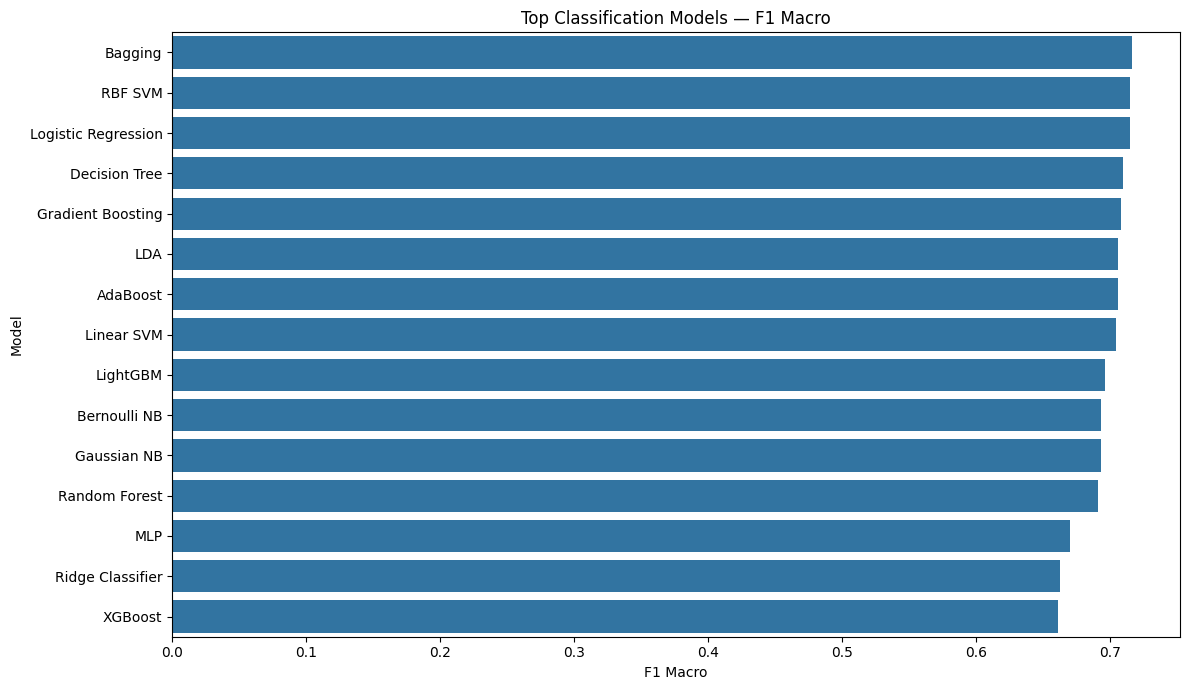

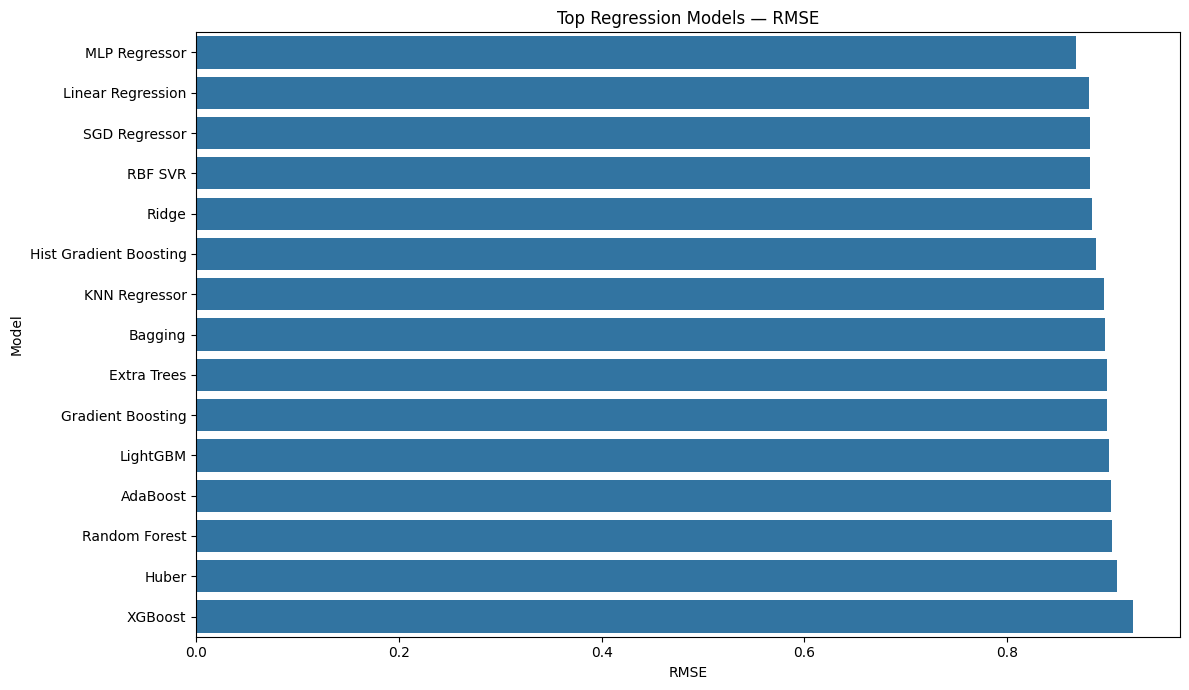

In [35]:
plt.figure(figsize=(12,7))
top = classification_results_df.head(15)
sns.barplot(data=top, y="Model", x="F1 Macro")
plt.title("Top Classification Models — F1 Macro")
plt.tight_layout()
plt.savefig(CLASS_DIR / "classification_f1_comparison.png", dpi=200)
plt.show()

plt.figure(figsize=(12,7))
top_reg = regression_results_df.head(15)
sns.barplot(data=top_reg, y="Model", x="RMSE")
plt.title("Top Regression Models — RMSE")
plt.tight_layout()
plt.savefig(REG_DIR / "regression_rmse_comparison.png", dpi=200)
plt.show()


## 20. Dashboard Integration

The generated files under `data/`, `models/`, and `outputs/` can be consumed directly by a Streamlit dashboard.

Suggested dashboard tabs:

1. **Overview**
2. **Dataset Statistics**
3. **EDA**
4. **Preprocessing**
5. **Feature Engineering**
6. **Classification Models**
7. **Regression Models**
8. **SHAP / Explainability**
9. **Prediction**
10. **Downloads**

Run a future Streamlit dashboard using:

```bash
streamlit run app.py
```

### Important research disclaimer
Predictions produced by this project are for educational/research demonstration only and must not be presented as a clinical diagnosis.
